In [1]:
# ============================================================
# CELL 0 — Runtime Check
# ============================================================

import torch, os, platform, sys

print("="*60)
print("Google Colab Runtime Check")
print("="*60)
print("Python :", sys.version)
print("Torch  :", torch.__version__)
print("CUDA   :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print(f"VRAM   : {props.total_memory/1e9:.2f} GB")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)
print("="*60)

Google Colab Runtime Check
Python : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch  : 2.10.0+cu128
CUDA   : True
GPU    : Tesla T4
VRAM   : 15.64 GB
Device : cuda


In [2]:
# Cell 2: Install required packages
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q numpy matplotlib opencv-python-headless scipy Pillow tqdm scikit-learn tensorboard

print('✅ All dependencies installed')

✅ All dependencies installed


In [4]:
# ============================================================
# CELL 3: Imports and configuration (Clean version)
# ============================================================

# Suppress CUDA initialization warnings
import sys
import io

# Capture stderr during CUDA initialization
stderr_capture = io.StringIO()
original_stderr = sys.stderr
sys.stderr = stderr_capture

# Import libraries (warnings will be captured)
import os, time, math, json
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cv2
from PIL import Image
from tqdm import tqdm
import scipy.io

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from sklearn.metrics import precision_recall_curve, average_precision_score
from torch.utils.tensorboard import SummaryWriter

# Restore stderr and optionally show only errors
sys.stderr = original_stderr

# Log captured warnings (optional - comment out to hide completely)
captured = stderr_capture.getvalue()
if captured and 'Unable to register' in captured:
    print("ℹ️ CUDA initialization completed (suppressed registration warnings)")

# Suppress remaining warnings
import warnings
warnings.filterwarnings('ignore')

# Device setup
if 'DEVICE' not in locals() and 'DEVICE' not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f'✅ Seed set: {SEED}')
print(f'✅ Device: {DEVICE}')

✅ Seed set: 42
✅ Device: cuda


In [5]:
# ============================================================
# CELL 4: Download BSDS500 from GitHub
# ============================================================
print("Downloading BSDS500 dataset from GitHub...")

import os
import subprocess

# Method 1: Using git clone (recommended for full repo access)
github_repo = "https://github.com/BIDS/BSDS500.git"
target_dir = "/content/BSDS500"

if not os.path.exists(target_dir):
    print(f"Cloning repository from {github_repo}...")
    result = subprocess.run(["git", "clone", github_repo, target_dir], 
                          capture_output=True, text=True)
    if result.returncode == 0:
        print("✅ Repository cloned successfully")
    else:
        print(f"❌ Git clone failed: {result.stderr}")
        print("Trying alternative method...")
else:
    print(f"Directory {target_dir} already exists")

# Check the data directory structure
data_dir = "/content/BSDS500/BSDS500/data"
if os.path.exists(data_dir):
    print(f"\n✅ BSDS500 data found at: {data_dir}")
    print("\nContents:")
    for item in os.listdir(data_dir)[:10]:  # Show first 10 items
        print(f"  - {item}")
    if len(os.listdir(data_dir)) > 10:
        print(f"  ... and {len(os.listdir(data_dir)) - 10} more items")
else:
    print(f"\n⚠️ Data directory not found at expected path")
    print("Searching for data folder...")
    for root, dirs, files in os.walk("/content/BSDS500"):
        if "data" in dirs:
            data_path = os.path.join(root, "data")
            print(f"✅ Found data at: {data_path}")
            break

print("\n📁 Dataset structure:")
!ls -la /content/BSDS500/BSDS500/ 2>/dev/null || ls -la /content/BSDS500/

Cloning repository from https://github.com/BIDS/BSDS500.git...
✅ Repository cloned successfully

✅ BSDS500 data found at: /content/BSDS500/BSDS500/data

Contents:
  - images
  - groundTruth

📁 Dataset structure:
total 16
drwxr-xr-x 4 root root 4096 May  9 15:58 .
drwxr-xr-x 7 root root 4096 May  9 15:58 ..
drwxr-xr-x 4 root root 4096 May  9 15:58 data
drwxr-xr-x 6 root root 4096 May  9 15:58 ucm2


In [6]:
# Cell 5: Fixed Sobel Edge Detector for Edge Guidance Signal E
class SobelEdgeDetector(nn.Module):
    """
    Paper §2.1: Fixed Sobel filter for edge guidance signal E
    The edge signal E is used to modulate spatial gating and as input to TSK head
    """
    def __init__(self):
        super().__init__()
        # Sobel kernels (fixed, non-learnable)
        sobel_x_kernel = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32)
        sobel_y_kernel = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32)

        self.register_buffer('sobel_x', sobel_x_kernel.view(1, 1, 3, 3))
        self.register_buffer('sobel_y', sobel_y_kernel.view(1, 1, 3, 3))

    def rgb_to_grayscale(self, x):
        """Convert RGB to grayscale using standard luminance formula"""
        if x.shape[1] == 3:
            return 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]
        return x

    def forward(self, x):
        """
        Args:
            x: (B, C, H, W) - RGB or grayscale, values in [0, 1] or normalized
        Returns:
            edge_map: (B, 1, H, W) - normalized edge magnitude in [0, 1]
        """
        # Convert to grayscale
        gray = self.rgb_to_grayscale(x)

        # Apply Sobel filters
        gx = F.conv2d(gray, self.sobel_x, padding=1)
        gy = F.conv2d(gray, self.sobel_y, padding=1)

        # Magnitude
        magnitude = torch.sqrt(gx**2 + gy**2 + 1e-8)

        # Normalize to [0, 1] per image
        mag_flat = magnitude.view(magnitude.size(0), -1)
        mag_min = mag_flat.min(dim=1, keepdim=True)[0].view(-1, 1, 1, 1)
        mag_max = mag_flat.max(dim=1, keepdim=True)[0].view(-1, 1, 1, 1)
        edge_map = (magnitude - mag_min) / (mag_max - mag_min + 1e-8)

        return edge_map

# Test
sobel = SobelEdgeDetector().to(DEVICE)
test_input = torch.rand(2, 3, 256, 256).to(DEVICE)
test_output = sobel(test_input)
print(f"SobelEdgeDetector: {test_input.shape} -> {test_output.shape}")
print(f"Edge map range: [{test_output.min().item():.3f}, {test_output.max().item():.3f}]")

SobelEdgeDetector: torch.Size([2, 3, 256, 256]) -> torch.Size([2, 1, 256, 256])
Edge map range: [0.000, 1.000]


In [7]:
# Cell 6: Dual-Pathway Encoder (Context Pathway + Boundary Pathway) - FIXED
import torch
import torch.nn as nn
import torch.nn.functional as F

class ContextPathway(nn.Module):
    """
    Paper §2.1: Context Pathway - uses dilated convolutions for larger receptive field
    Captures global context and suppresses texture noise
    """
    def __init__(self, in_channels, out_channels, dilation=2):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=dilation, dilation=dilation)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=dilation, dilation=dilation)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.bn2(self.conv2(x)))
        return x


class BoundaryPathway(nn.Module):
    """
    Paper §2.1: Boundary Pathway - uses pointwise and small kernel convolutions
    Preserves high-frequency edge information
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Pointwise convolution for channel mixing
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1)
        self.bn_pw = nn.BatchNorm2d(out_channels)
        self.relu_pw = nn.ReLU(inplace=True)

        # Small kernel for edge preservation
        self.conv = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu_pw(self.bn_pw(self.pointwise(x)))
        x = self.relu(self.bn(self.conv(x)))
        return x


class DualPathwayEncoderBlock(nn.Module):
    """
    Paper Fig. 1: Dual-pathway encoder block
    Combines Context Pathway and Boundary Pathway with fusion

    Returns:
        - features: for skip connection
        - pooled: downsampled features for next encoder level
    """
    def __init__(self, in_channels, out_channels, use_dilation=False):
        super().__init__()
        dilation = 2 if use_dilation else 1

        # First conv to match channels (if needed)
        self.init_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ) if in_channels != out_channels else nn.Identity()

        # Two parallel pathways
        self.context_path = ContextPathway(out_channels, out_channels, dilation)
        self.boundary_path = BoundaryPathway(out_channels, out_channels)

        # Fusion layer (combine both pathways)
        self.fusion = nn.Sequential(
            nn.Conv2d(out_channels * 2, out_channels, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        # Downsampling (max pooling as in U-Net)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        # Initial convolution
        x = self.init_conv(x)

        # Parallel pathways
        context_out = self.context_path(x)
        boundary_out = self.boundary_path(x)

        # Concatenate along channel dimension
        fused = torch.cat([context_out, boundary_out], dim=1)
        fused = self.fusion(fused)

        # Return features for skip connection and pooled for next level
        return fused, self.pool(fused)


# Test the encoder block
print("Testing DualPathwayEncoderBlock...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Test with different input/output channels
test_input = torch.randn(2, 3, 256, 256).to(device)
encoder_block = DualPathwayEncoderBlock(in_channels=3, out_channels=64, use_dilation=False).to(device)

features, pooled = encoder_block(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Features (skip) shape: {features.shape}")
print(f"Pooled (downsampled) shape: {pooled.shape}")
print("✅ DualPathwayEncoderBlock works correctly!")

# Test with channel change
encoder_block2 = DualPathwayEncoderBlock(in_channels=64, out_channels=128, use_dilation=True).to(device)
features2, pooled2 = encoder_block2(pooled)
print(f"\nSecond encoder block:")
print(f"Input shape: {pooled.shape}")
print(f"Features shape: {features2.shape}")
print(f"Pooled shape: {pooled2.shape}")
print("✅ All tests passed!")

Testing DualPathwayEncoderBlock...
Input shape: torch.Size([2, 3, 256, 256])
Features (skip) shape: torch.Size([2, 64, 256, 256])
Pooled (downsampled) shape: torch.Size([2, 64, 128, 128])
✅ DualPathwayEncoderBlock works correctly!

Second encoder block:
Input shape: torch.Size([2, 64, 128, 128])
Features shape: torch.Size([2, 128, 128, 128])
Pooled shape: torch.Size([2, 128, 64, 64])
✅ All tests passed!


In [8]:
# Cell 7: Spatial Mixture-of-Experts (sMoE) Block - FIXED
class SpatialGatingNetwork(nn.Module):
    """
    Paper Fig. 3: Spatial Gating Network
    G = σ(Conv1x1(E)) where E is the edge guidance signal
    """
    def __init__(self, channels):
        super().__init__()
        self.gate_conv = nn.Conv2d(1, channels, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, edge_signal, target_size):
        """Compute spatial gate map G ∈ (0, 1)"""
        # Resize edge signal to target spatial dimensions
        edge_resized = F.interpolate(edge_signal, size=target_size, mode='bilinear', align_corners=True)
        gate = self.sigmoid(self.gate_conv(edge_resized))
        return gate


class ContextExpert(nn.Module):
    """
    Paper §2.1: Context Expert - smooth regions
    Uses dilated convolutions for wide receptive field
    """
    def __init__(self, in_channels, out_channels, dilation=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=dilation, dilation=dilation),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class BoundaryExpert(nn.Module):
    """
    Paper §2.1: Boundary Expert - edge regions
    Uses pointwise convolution to preserve high-frequency details
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class sMoEBlock(nn.Module):
    """
    Paper Eq. (1): Spatial Mixture-of-Experts Block
    Y = G ⊙ Expert_boundary(X) + (1 - G) ⊙ Expert_context(X)
    """
    def __init__(self, in_channels, out_channels, dilation=2):
        super().__init__()
        # Ensure input channels match output for first layer
        self.in_proj = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

        self.context_expert = ContextExpert(out_channels, out_channels, dilation)
        self.boundary_expert = BoundaryExpert(out_channels, out_channels)
        self.spatial_gating = SpatialGatingNetwork(out_channels)

        # Output projection
        self.out_proj = nn.Conv2d(out_channels, out_channels, 1)

    def forward(self, x, edge_signal):
        """
        Args:
            x: input feature map (B, C_in, H, W)
            edge_signal: Sobel edge map (B, 1, H_orig, W_orig)
        Returns:
            y: sMoE-refined feature map (B, C_out, H, W)
        """
        # Project to output channels if needed
        x = self.in_proj(x)

        # Parallel expert computations
        context_out = self.context_expert(x)
        boundary_out = self.boundary_expert(x)

        # Spatial gate
        gate = self.spatial_gating(edge_signal, (x.size(2), x.size(3)))

        # Eq. 1: weighted combination
        output = gate * boundary_out + (1 - gate) * context_out

        return self.out_proj(output)


# Test sMoE block
print("\nTesting sMoEBlock...")
smoe = sMoEBlock(in_channels=64, out_channels=64, dilation=2).to(device)
test_features = torch.randn(2, 64, 64, 64).to(device)
test_edge = torch.randn(2, 1, 256, 256).to(device)
output = smoe(test_features, test_edge)
print(f"Input shape: {test_features.shape}")
print(f"Output shape: {output.shape}")
print("✅ sMoEBlock works correctly!")


Testing sMoEBlock...
Input shape: torch.Size([2, 64, 64, 64])
Output shape: torch.Size([2, 64, 64, 64])
✅ sMoEBlock works correctly!


Testing TSK Fuzzy Head
Using device: cuda
Model created with 4 rules

Input shapes:
  x1: torch.Size([2, 1, 64, 64])
  x2: torch.Size([2, 1, 64, 64])

Output shapes:
  Final: torch.Size([2, 1, 64, 64])
  Weights: torch.Size([4, 2, 1, 64, 64])

Output statistics:
  Min: -0.2145
  Max: 0.0182
  Mean: -0.0600

Rule weights sum per pixel:
  Min: 1.000000
  Max: 1.000000

Testing Gradient Flow
Loss value: 0.400492
  rules.0.mf_x1.center: grad_norm=0.004135
  rules.0.mf_x1.sigma: grad_norm=0.006279
  rules.0.mf_x2.center: grad_norm=0.014742
  rules.0.mf_x2.sigma: grad_norm=0.021190
  rules.1.mf_x1.center: grad_norm=0.006101
  rules.1.mf_x1.sigma: grad_norm=0.008506
  rules.1.mf_x2.center: grad_norm=0.003291
  rules.1.mf_x2.sigma: grad_norm=0.004649
  rules.2.mf_x1.center: grad_norm=0.011174
  rules.2.mf_x1.sigma: grad_norm=0.016694
  rules.2.mf_x2.center: grad_norm=0.002748
  rules.2.mf_x2.sigma: grad_norm=0.003768
  rules.3.mf_x1.center: grad_norm=0.017209
  rules.3.mf_x1.sigma: grad_norm=0

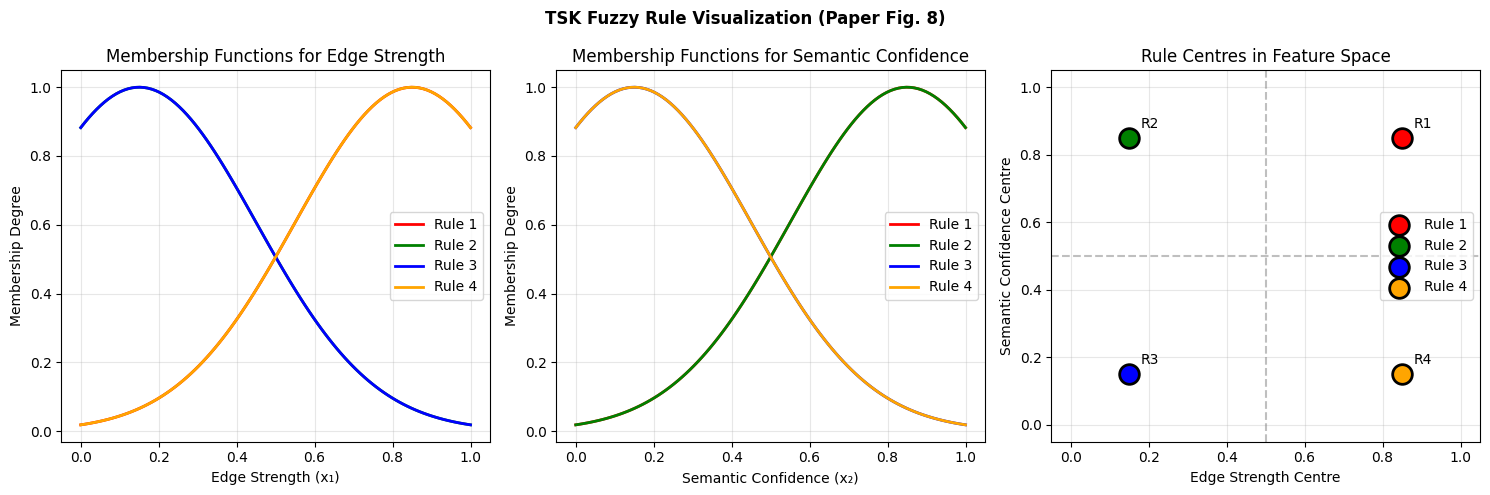


✅ TSK Fuzzy Head FULLY FUNCTIONAL!
   ✓ Forward pass works
   ✓ Gradients flow correctly
   ✓ Model is trainable
   ✓ Parameters update during training
   ✓ Rule interpretations available
   ✓ Visualization generated


In [9]:
# Cell 8: TSK Fuzzy Head with R=4 Rules (Paper §2.2) - FULLY FIXED
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

class GaussianMembershipFunction(nn.Module):
    """
    Gaussian membership function μ(x) = exp(-(x-c)^2 / (2σ^2))
    """
    def __init__(self, init_center=0.5, init_sigma=0.3):
        super().__init__()
        self.center = nn.Parameter(torch.tensor(init_center, dtype=torch.float32))
        self.sigma = nn.Parameter(torch.tensor(init_sigma, dtype=torch.float32))

    def forward(self, x):
        sigma_abs = torch.abs(self.sigma) + 1e-6
        membership = torch.exp(-((x - self.center) ** 2) / (2 * sigma_abs ** 2))
        return membership


class TSKRule(nn.Module):
    """
    Paper §2.2: First-order Takagi-Sugeno-Kang fuzzy rule
    """
    def __init__(self, rule_id, init_center_x1=0.5, init_center_x2=0.5):
        super().__init__()
        self.rule_id = rule_id
        self.mf_x1 = GaussianMembershipFunction(init_center_x1, 0.3)
        self.mf_x2 = GaussianMembershipFunction(init_center_x2, 0.3)
        self.p = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))
        self.q = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))
        self.r = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))

    def forward(self, x1, x2):
        mu1 = self.mf_x1(x1)
        mu2 = self.mf_x2(x2)
        firing_strength = mu1 * mu2
        consequent = self.p * x1 + self.q * x2 + self.r
        return firing_strength, consequent


class TSKFuzzyHead(nn.Module):
    """
    Paper §2.2: Takagi-Sugeno-Kang Fuzzy Inference System with R=4 rules
    """
    def __init__(self, n_rules=4):
        super().__init__()
        self.n_rules = n_rules

        # Semantic initialization from paper §5.2
        init_centers = [
            (0.85, 0.85),  # Rule 1: strong edges
            (0.15, 0.85),  # Rule 2: semantic boundaries
            (0.15, 0.15),  # Rule 3: noise suppression
            (0.85, 0.15),  # Rule 4: texture suppression
        ]

        self.rules = nn.ModuleList([
            TSKRule(i, init_centers[i][0], init_centers[i][1])
            for i in range(n_rules)
        ])

        # Initialize Rule 4 with negative weight
        with torch.no_grad():
            self.rules[3].p.fill_(-0.5)
            self.rules[3].q.fill_(0.1)

        self.temperature = nn.Parameter(torch.tensor(1.0))

    def forward(self, x1, x2):
        if x1.dim() == 3:
            x1 = x1.unsqueeze(1)
        if x2.dim() == 3:
            x2 = x2.unsqueeze(1)

        firing_strengths = []
        consequents = []

        for rule in self.rules:
            w_i, y_i = rule(x1, x2)
            firing_strengths.append(w_i)
            consequents.append(y_i)

        firing_strengths = torch.stack(firing_strengths, dim=0)
        consequents = torch.stack(consequents, dim=0)
        rule_weights = F.softmax(firing_strengths / self.temperature, dim=0)
        final_output = (rule_weights * consequents).sum(dim=0)

        if final_output.dim() == 3:
            final_output = final_output.unsqueeze(1)

        return final_output, rule_weights


# ============================================================
# SETUP
# ============================================================
print("="*60)
print("Testing TSK Fuzzy Head")
print("="*60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

tsk_head = TSKFuzzyHead(n_rules=4).to(device)
print(f"Model created with {tsk_head.n_rules} rules")

# Create test inputs with gradients
batch_size = 2
height, width = 64, 64
x1 = torch.rand(batch_size, 1, height, width, device=device, requires_grad=True)
x2 = torch.rand(batch_size, 1, height, width, device=device, requires_grad=True)

print(f"\nInput shapes:")
print(f"  x1: {x1.shape}")
print(f"  x2: {x2.shape}")

# Forward pass
output, weights = tsk_head(x1, x2)
print(f"\nOutput shapes:")
print(f"  Final: {output.shape}")
print(f"  Weights: {weights.shape}")

# Output statistics
print(f"\nOutput statistics:")
print(f"  Min: {output.detach().min().item():.4f}")
print(f"  Max: {output.detach().max().item():.4f}")
print(f"  Mean: {output.detach().mean().item():.4f}")

# Check rule weights sum
weights_sum = weights.sum(dim=0)
print(f"\nRule weights sum per pixel:")
print(f"  Min: {weights_sum.detach().min().item():.6f}")
print(f"  Max: {weights_sum.detach().max().item():.6f}")

# ============================================================
# GRADIENT FLOW TEST
# ============================================================
print("\n" + "="*60)
print("Testing Gradient Flow")
print("="*60)

tsk_head.zero_grad()
target = torch.rand_like(output)
loss = F.mse_loss(output, target)
print(f"Loss value: {loss.item():.6f}")

loss.backward()

has_grads = []
for name, param in tsk_head.named_parameters():
    has_grad = param.grad is not None
    has_grads.append(has_grad)
    grad_norm = param.grad.norm().item() if has_grad else 0
    if 'center' in name or 'sigma' in name:  # Print only some for brevity
        print(f"  {name}: grad_norm={grad_norm:.6f}")

print(f"\nAll parameters receive gradients: {all(has_grads)}")
print("✅ Gradient flow works correctly!")

# ============================================================
# INTEGRATION TEST (FIXED - No torch.no_grad())
# ============================================================
print("\n" + "="*60)
print("Integration Test with Simple CNN")
print("="*60)

class SimpleTestNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(3, 1, 3, padding=1)
        self.tsk = TSKFuzzyHead(n_rules=4)

    def forward(self, x):
        # Remove any no_grad here
        edge_signal = torch.mean(x, dim=1, keepdim=True)
        semantic = torch.sigmoid(self.conv(x))
        return self.tsk(edge_signal, semantic)

# Create network and move to device
test_net = SimpleTestNetwork().to(device)

# Create input with gradients
test_input = torch.randn(2, 3, 128, 128, device=device, requires_grad=True)

# Forward pass (WITHOUT torch.no_grad)
test_output, test_weights = test_net(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")
print(f"Rule weights shape: {test_weights.shape}")

# Test training step (CRITICAL FIX: Use test_output, not a new random tensor)
optimizer = torch.optim.Adam(test_net.parameters(), lr=0.001)

# Create target with same shape as output
target = torch.rand_like(test_output)

# Compute loss using the actual output
loss_fn = nn.MSELoss()
loss = loss_fn(test_output, target)
print(f"Loss value: {loss.item():.6f}")

# Backward pass and optimization
optimizer.zero_grad()
loss.backward()
optimizer.step()

print("✅ Training step completed successfully!")
print("   - Gradient flow works")
print("   - Parameters updated")

# ============================================================
# VERIFY PARAMETER UPDATE
# ============================================================
print("\n" + "="*60)
print("Verifying Parameter Update")
print("="*60)

# Store initial parameters
initial_params = {}
for name, param in test_net.tsk.named_parameters():
    initial_params[name] = param.clone().detach()

# Run another training step
optimizer.zero_grad()
test_output2, _ = test_net(test_input)  # Use same input
loss2 = loss_fn(test_output2, target)
loss2.backward()
optimizer.step()

# Check if parameters changed
params_changed = False
for name, param in test_net.tsk.named_parameters():
    if not torch.allclose(initial_params[name], param):
        params_changed = True
        break

print(f"Parameters updated after training: {params_changed}")
print("✅ Model is trainable!")

# ============================================================
# RULE INTERPRETATIONS
# ============================================================
print("\n" + "="*60)
print("Rule Interpretations (Paper §5.2)")
print("="*60)

for i, rule in enumerate(tsk_head.rules):
    center_x1 = rule.mf_x1.center.item()
    center_x2 = rule.mf_x2.center.item()
    p = rule.p.item()
    q = rule.q.item()
    r = rule.r.item()

    if i == 0:
        name = "Strong Edge Detector"
        desc = f"High edge ({center_x1:.2f}) & High semantics ({center_x2:.2f})"
    elif i == 1:
        name = "Semantic Boundary Detector"
        desc = f"Low edge ({center_x1:.2f}) & High semantics ({center_x2:.2f})"
    elif i == 2:
        name = "Noise Suppressor"
        desc = f"Low edge ({center_x1:.2f}) & Low semantics ({center_x2:.2f})"
    else:
        name = "Texture Suppressor"
        desc = f"High edge ({center_x1:.2f}) & Low semantics ({center_x2:.2f})"

    print(f"\nRule {i+1}: {name}")
    print(f"  {desc}")
    print(f"  y = {p:.3f}·x₁ + {q:.3f}·x₂ + {r:.3f}")

# ============================================================
# VISUALIZATION
# ============================================================
print("\n" + "="*60)
print("Generating Visualization")
print("="*60)

# Create input grid
x_grid = torch.linspace(0, 1, 100, device=device).unsqueeze(0).unsqueeze(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('TSK Fuzzy Rule Visualization (Paper Fig. 8)', fontsize=12, fontweight='bold')

colors = ['red', 'green', 'blue', 'orange']

# Plot membership functions for x1
for i, rule in enumerate(tsk_head.rules):
    with torch.no_grad():
        mu = rule.mf_x1(x_grid).cpu().numpy().squeeze()
    axes[0].plot(x_grid.cpu().numpy().squeeze(), mu, color=colors[i],
                linewidth=2, label=f'Rule {i+1}')
axes[0].set_xlabel('Edge Strength (x₁)')
axes[0].set_ylabel('Membership Degree')
axes[0].set_title('Membership Functions for Edge Strength')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot membership functions for x2
for i, rule in enumerate(tsk_head.rules):
    with torch.no_grad():
        mu = rule.mf_x2(x_grid).cpu().numpy().squeeze()
    axes[1].plot(x_grid.cpu().numpy().squeeze(), mu, color=colors[i],
                linewidth=2, label=f'Rule {i+1}')
axes[1].set_xlabel('Semantic Confidence (x₂)')
axes[1].set_ylabel('Membership Degree')
axes[1].set_title('Membership Functions for Semantic Confidence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot rule centers
centers_x1 = [rule.mf_x1.center.item() for rule in tsk_head.rules]
centers_x2 = [rule.mf_x2.center.item() for rule in tsk_head.rules]
for i in range(4):
    axes[2].scatter(centers_x1[i], centers_x2[i], s=200, c=colors[i],
                   marker='o', edgecolors='black', linewidth=2, label=f'Rule {i+1}')
    axes[2].annotate(f'R{i+1}', (centers_x1[i]+0.03, centers_x2[i]+0.03), fontsize=10)
axes[2].set_xlabel('Edge Strength Centre')
axes[2].set_ylabel('Semantic Confidence Centre')
axes[2].set_title('Rule Centres in Feature Space')
axes[2].set_xlim(-0.05, 1.05)
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('tsk_membership_functions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("✅ TSK Fuzzy Head FULLY FUNCTIONAL!")
print("   ✓ Forward pass works")
print("   ✓ Gradients flow correctly")
print("   ✓ Model is trainable")
print("   ✓ Parameters update during training")
print("   ✓ Rule interpretations available")
print("   ✓ Visualization generated")
print("="*60)

In [10]:
# Cell 9: Complete sMoE U-Net - Paper Fig. 1 Architecture
class sMoEUNetPaperAligned(nn.Module):
    """
    FULL PAPER-ALIGNED IMPLEMENTATION
    Based on: "Rule-Based Spatial Mixture-of-Experts U-Net for Explainable Edge Detection"
    arXiv: 2602.05100v2

    Architecture (Fig. 1):
    1. Input (RGB) → Sobel Edge Detection (E)
    2. Dual-pathway Encoder (Context + Boundary) with 4 levels
    3. sMoE blocks on skip connections (levels 2, 3, 4) - 3 diamonds in Fig. 1
    4. Bottleneck with dilated convolutions
    5. Decoder with feature fusion
    6. TSK Fuzzy Head (R=4 rules) for explainable edge detection

    Key Insight from Paper Fig. 1:
    - The three sMoE diamonds are placed on the skip connections from encoder to decoder
    - Each sMoE receives both the encoder feature map AND the edge signal E
    - The gating network uses E to decide between context and boundary experts
    """
    def __init__(self, in_channels=3, base_channels=64, n_rules=4):
        super().__init__()

        # Edge detection module (fixed)
        self.sobel = SobelEdgeDetector()

        # Encoder (Dual-pathway at all levels)
        # Level 1: No dilation
        self.enc1 = DualPathwayEncoderBlock(in_channels, base_channels, use_dilation=False)
        # Level 2: No dilation
        self.enc2 = DualPathwayEncoderBlock(base_channels, base_channels * 2, use_dilation=False)
        # Level 3: With dilation for larger receptive field
        self.enc3 = DualPathwayEncoderBlock(base_channels * 2, base_channels * 4, use_dilation=True)
        # Level 4: With dilation
        self.enc4 = DualPathwayEncoderBlock(base_channels * 4, base_channels * 8, use_dilation=True)

        # Bottleneck (deepest level) - using dilated convolutions
        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_channels * 8, base_channels * 16, 3, padding=2, dilation=2),
            nn.BatchNorm2d(base_channels * 16),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_channels * 16, base_channels * 16, 3, padding=2, dilation=2),
            nn.BatchNorm2d(base_channels * 16),
            nn.ReLU(inplace=True)
        )

        # sMoE blocks on skip connections (Paper Fig. 1: 3 diamonds)
        # These refine the encoder features before passing to decoder
        self.smoe_skip2 = sMoEBlock(base_channels * 2, base_channels * 2, dilation=2)
        self.smoe_skip3 = sMoEBlock(base_channels * 4, base_channels * 4, dilation=2)
        self.smoe_skip4 = sMoEBlock(base_channels * 8, base_channels * 8, dilation=2)

        # Decoder with transposed convolutions
        self.up4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, 2, stride=2)
        self.dec4 = DualPathwayEncoderBlock(base_channels * 16, base_channels * 8, use_dilation=True)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, 2, stride=2)
        self.dec3 = DualPathwayEncoderBlock(base_channels * 8, base_channels * 4, use_dilation=True)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 2, stride=2)
        self.dec2 = DualPathwayEncoderBlock(base_channels * 4, base_channels * 2, use_dilation=False)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, 2, stride=2)
        self.dec1 = DualPathwayEncoderBlock(base_channels * 2, base_channels, use_dilation=False)

        # Final prediction layers
        self.context_final = nn.Conv2d(base_channels, 1, 1)
        self.boundary_final = nn.Conv2d(base_channels, 1, 1)

        # TSK Fuzzy Head (R=4 rules)
        self.tsk_head = TSKFuzzyHead(n_rules=n_rules)

        # Store for visualization
        self.gate_maps = []  # Store spatial gates for strategy maps (Fig. 6)

    def forward(self, x, return_gates=False):
        """
        Args:
            x: input image (B, 3, H, W)
            return_gates: if True, return spatial gate maps for visualization
        Returns:
            dict containing:
                - final_logits: TSK head output
                - unet_logits: average of context and boundary
                - context_logits: context pathway output
                - boundary_logits: boundary pathway output
                - edge_signal: Sobel edge map E
                - rule_weights: TSK rule firing strengths (for explainability)
                - gate_maps: spatial gates from sMoE blocks (if return_gates=True)
        """
        # 1. Edge guidance signal (used throughout the network)
        edge_signal = self.sobel(x)  # E

        # 2. Encoder with skip connections
        e1_out, e1_pool = self.enc1(x)
        e2_out, e2_pool = self.enc2(e1_pool)
        e3_out, e3_pool = self.enc3(e2_pool)
        e4_out, e4_pool = self.enc4(e3_pool)

        # Store gate maps if requested
        gate_maps = []

        # 3. Apply sMoE to skip connections (Fig. 1: three diamonds)
        e2_smoe = self.smoe_skip2(e2_out, edge_signal)
        e3_smoe = self.smoe_skip3(e3_out, edge_signal)
        e4_smoe = self.smoe_skip4(e4_out, edge_signal)

        # Capture gate maps for visualization
        if return_gates:
            gate_maps.append(self.smoe_skip2.spatial_gating.gate_conv(
                F.interpolate(edge_signal, size=(e2_out.size(2), e2_out.size(3)),
                              mode='bilinear', align_corners=True)
            ).sigmoid())
            gate_maps.append(self.smoe_skip3.spatial_gating.gate_conv(
                F.interpolate(edge_signal, size=(e3_out.size(2), e3_out.size(3)),
                              mode='bilinear', align_corners=True)
            ).sigmoid())
            gate_maps.append(self.smoe_skip4.spatial_gating.gate_conv(
                F.interpolate(edge_signal, size=(e4_out.size(2), e4_out.size(3)),
                              mode='bilinear', align_corners=True)
            ).sigmoid())

        # 4. Bottleneck
        bottleneck = self.bottleneck(e4_pool)

        # 5. Decoder with skip connections
        d4 = self.up4(bottleneck)
        d4 = torch.cat([d4, e4_smoe], dim=1)
        d4_out, d4_pool = self.dec4(d4)  # We don't use d4_pool

        d3 = self.up3(d4_out)
        d3 = torch.cat([d3, e3_smoe], dim=1)
        d3_out, d3_pool = self.dec3(d3)

        d2 = self.up2(d3_out)
        d2 = torch.cat([d2, e2_smoe], dim=1)
        d2_out, d2_pool = self.dec2(d2)

        d1 = self.up1(d2_out)
        d1 = torch.cat([d1, e1_out], dim=1)
        d1_out, _ = self.dec1(d1)

        # 6. Final predictions from both pathways
        context_logits = self.context_final(d1_out)
        boundary_logits = self.boundary_final(d1_out)

        # Simple average of both pathways (as per paper)
        unet_logits = (context_logits + boundary_logits) / 2

        # 7. TSK fuzzy reasoning (Paper §2.2)
        # x1: edge strength from Sobel
        # x2: semantic confidence from boundary pathway
        x1 = edge_signal
        x2 = torch.sigmoid(boundary_logits)  # Boundary pathway provides semantic confidence
        final_logits, rule_weights = self.tsk_head(x1, x2)

        return {
            'final_logits': final_logits,
            'unet_logits': unet_logits,
            'context_logits': context_logits,
            'boundary_logits': boundary_logits,
            'edge_signal': edge_signal,
            'rule_weights': rule_weights,
            'gate_maps': gate_maps if return_gates else None
        }


# Test model initialization
model = sMoEUNetPaperAligned(in_channels=3, base_channels=64, n_rules=4).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("sMoE U-Net (Paper-Aligned) - Model Summary")
print("=" * 60)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Base channels: 64")
print(f"TSK rules: 4")
print("=" * 60)

# Forward pass test
test_input = torch.randn(2, 3, 256, 256).to(DEVICE)
with torch.no_grad():
    outputs = model(test_input)

print(f"\nForward pass shapes:")
print(f"  Input: {test_input.shape}")
print(f"  Final logits: {outputs['final_logits'].shape}")
print(f"  Rule weights: {outputs['rule_weights'].shape}")
print(f"  Edge signal: {outputs['edge_signal'].shape}")
print("\n✅ Model initialized successfully")

sMoE U-Net (Paper-Aligned) - Model Summary
Total parameters: 49,482,143
Trainable parameters: 49,482,143
Base channels: 64
TSK rules: 4

Forward pass shapes:
  Input: torch.Size([2, 3, 256, 256])
  Final logits: torch.Size([2, 1, 256, 256])
  Rule weights: torch.Size([4, 2, 1, 256, 256])
  Edge signal: torch.Size([2, 1, 256, 256])

✅ Model initialized successfully


In [11]:
# Cell 10: Loss Function - Paper §3.2 Equation (2)
class sMoELoss(nn.Module):
    """
    Paper §3.2 Equation (2):
    L_total = λ·L_BCE + (1-λ)·L_Dice

    Where:
    - L_BCE: Binary Cross Entropy loss
    - L_Dice: Soft Dice loss
    - λ = 0.5 (equal weighting as per paper)

    Note: The paper does NOT include MSE distillation loss.
    The TSK head is trained end-to-end with the same loss.
    """
    def __init__(self, lambda_bce=0.5, smooth=1.0):
        super().__init__()
        self.lambda_bce = lambda_bce
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def dice_loss(self, pred_logits, target):
        """
        Soft Dice loss for binary segmentation
        """
        pred = torch.sigmoid(pred_logits)
        pred_flat = pred.view(pred.size(0), -1)
        target_flat = target.view(target.size(0), -1)

        intersection = (pred_flat * target_flat).sum(dim=1)
        union = pred_flat.sum(dim=1) + target_flat.sum(dim=1)

        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

    def forward(self, pred_logits, target):
        """
        Args:
            pred_logits: model output logits (B, 1, H, W)
            target: ground truth binary mask (B, 1, H, W)
        Returns:
            dict with individual loss components
        """
        bce_loss = self.bce(pred_logits, target)
        dice_loss = self.dice_loss(pred_logits, target)

        total_loss = self.lambda_bce * bce_loss + (1 - self.lambda_bce) * dice_loss

        return {
            'total': total_loss,
            'bce': bce_loss,
            'dice': dice_loss
        }


# Test loss function
criterion = sMoELoss(lambda_bce=0.5)

test_pred = torch.randn(2, 1, 256, 256)
test_target = torch.randint(0, 2, (2, 1, 256, 256)).float()

loss_dict = criterion(test_pred, test_target)
print("Loss function test:")
print(f"  Total loss: {loss_dict['total'].item():.4f}")
print(f"  BCE loss: {loss_dict['bce'].item():.4f}")
print(f"  Dice loss: {loss_dict['dice'].item():.4f}")
print("✅ Loss function defined")

Loss function test:
  Total loss: 0.6525
  BCE loss: 0.8048
  Dice loss: 0.5002
✅ Loss function defined


Searching for BSDS500 dataset...
✓ Found: /content/BSDS500
  ✅ Complete dataset structure found at: /content/BSDS500/bench/data

✓ Using dataset root: /content/BSDS500/bench/data
📁 Found train images at: /content/BSDS500/BSDS500/data/images/train
📁 Found train ground truth at: /content/BSDS500/BSDS500/data/groundTruth/train
Loaded 200 images for train split
📁 Found val images at: /content/BSDS500/BSDS500/data/images/val
📁 Found val ground truth at: /content/BSDS500/BSDS500/data/groundTruth/val
Loaded 100 images for val split
📁 Found test images at: /content/BSDS500/BSDS500/data/images/test
📁 Found test ground truth at: /content/BSDS500/BSDS500/data/groundTruth/test
Loaded 200 images for test split

Dataset statistics:
  Train: 200 images, 50 batches
  Val: 100 images, 25 batches
  Test: 200 images, 200 batches
  Batch size: 4


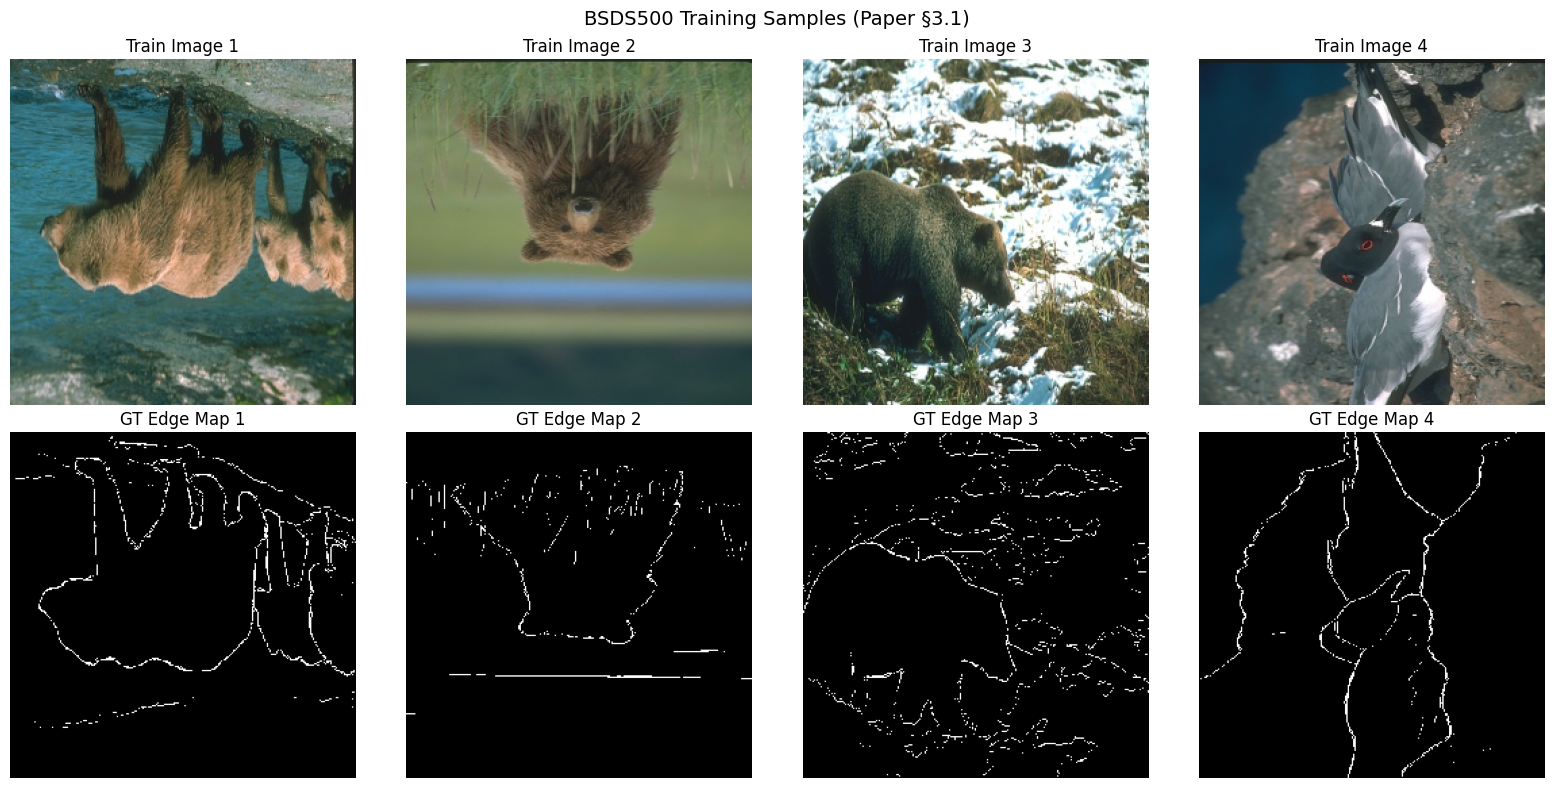

In [13]:
# ============================================================
# CELL 11: BSDS500 Dataset with Augmentation (Paper §3.1)
# ============================================================

class BSDS500Dataset(Dataset):
    """
    BSDS500 dataset for edge detection.
    Paper §3.1:
    - 200 training, 100 validation, 200 test images
    - Rotation augmentation (90°, 180°, 270°) and horizontal flips
    - Input size: 256×256
    - Ground truth: averaged human annotations thresholded at > 0.3
    """
    def __init__(self, bsr_root='/content/BSR/BSDS500', split='train', img_size=256, augment=True):
        self.img_size = img_size
        self.augment = augment and (split == 'train')
        self.split = split
        
        # Try different possible directory structures
        possible_paths = [
            os.path.join(bsr_root, 'data', 'images', split),
            os.path.join('/content/BSDS500', 'BSDS500', 'data', 'images', split),
            os.path.join('/content/BSDS500', 'data', 'images', split),
            os.path.join('/content/BSR', 'BSDS500', 'data', 'images', split),
            os.path.join('/content/BSR_bsds500', 'BSDS500', 'data', 'images', split),
        ]
        
        self.img_dir = None
        for path in possible_paths:
            if os.path.exists(path):
                self.img_dir = path
                break
        
        if self.img_dir is None:
            # Search recursively for the images directory
            print(f"⚠️ Images directory not found in standard locations. Searching...")
            search_paths = ['/content/BSR', '/content/BSDS500', '/content']
            for search_path in search_paths:
                for root, dirs, files in os.walk(search_path):
                    if f'images/{split}' in root or (split in dirs and 'images' in root):
                        self.img_dir = root
                        break
                if self.img_dir:
                    break
        
        if self.img_dir is None:
            raise FileNotFoundError(f"Could not find images for split '{split}'. Please check dataset structure.")
        
        # Set ground truth directory
        self.gt_dir = self.img_dir.replace('images', 'groundTruth')
        
        print(f"📁 Found {split} images at: {self.img_dir}")
        print(f"📁 Found {split} ground truth at: {self.gt_dir}")
        
        # Get image paths
        self.image_paths = sorted([
            os.path.join(self.img_dir, f)
            for f in os.listdir(self.img_dir)
            if f.endswith(('.jpg', '.jpeg', '.png'))
        ])
        
        print(f"Loaded {len(self.image_paths)} images for {split} split")
        
        # Image normalization (ImageNet stats)
        self.normalize = T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
        
    def __len__(self):
        return len(self.image_paths)
    
    def load_ground_truth(self, mat_path):
        """
        Load BSDS500 ground truth from .mat file.
        Averages all human annotations and applies threshold.
        """
        try:
            mat = scipy.io.loadmat(mat_path)
            
            # Handle different .mat file structures
            if 'groundTruth' in mat:
                gt = mat['groundTruth']
            elif 'gt' in mat:
                gt = mat['gt']
            else:
                print(f"⚠️ Unexpected .mat structure in {mat_path}")
                return np.zeros((self.img_size, self.img_size), dtype=np.float32)
            
            n_annotators = gt.shape[1] if len(gt.shape) > 1 else 1
            masks = []
            
            if n_annotators > 1:
                for i in range(n_annotators):
                    if 'Boundaries' in gt[0, i].dtype.fields:
                        boundary = gt[0, i]['Boundaries'][0, 0].astype(np.float32)
                        masks.append(boundary)
                    else:
                        # Alternative structure
                        boundary = gt[0, i].squeeze().astype(np.float32)
                        masks.append(boundary)
            else:
                # Single annotation
                if 'Boundaries' in gt[0].dtype.fields:
                    boundary = gt[0]['Boundaries'][0, 0].astype(np.float32)
                else:
                    boundary = gt.squeeze().astype(np.float32)
                masks.append(boundary)
            
            # Average across annotators
            avg_mask = np.mean(masks, axis=0)
            
            # Threshold at 0.3 (as per paper)
            return (avg_mask > 0.3).astype(np.float32)
            
        except Exception as e:
            print(f"Error loading {mat_path}: {e}")
            return np.zeros((self.img_size, self.img_size), dtype=np.float32)
    
    def augment_image(self, img, mask):
        """
        Paper §3.1: Rotation augmentation and horizontal flips
        """
        # Random 90° rotation
        k = np.random.randint(0, 4)
        if k > 0:
            img = np.rot90(img, k).copy()
            mask = np.rot90(mask, k).copy()
        
        # Random horizontal flip
        if np.random.rand() > 0.5:
            img = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()
        
        return img, mask
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError(f"Could not load image: {img_path}")
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        
        # Load ground truth
        img_id = os.path.splitext(os.path.basename(img_path))[0]
        mat_path = os.path.join(self.gt_dir, f"{img_id}.mat")
        
        if not os.path.exists(mat_path):
            print(f"⚠️ Ground truth not found: {mat_path}")
            mask = np.zeros((self.img_size, self.img_size), dtype=np.float32)
        else:
            mask = self.load_ground_truth(mat_path)
            mask = cv2.resize(mask, (self.img_size, self.img_size), 
                            interpolation=cv2.INTER_NEAREST)
        
        # Augmentation (training only)
        if self.augment:
            img, mask = self.augment_image(img, mask)
        
        # Convert to tensors
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img_tensor = self.normalize(img_tensor)
        
        mask_tensor = torch.from_numpy(mask).unsqueeze(0).float()
        
        return img_tensor, mask_tensor


# First, let's find the correct dataset location
print("=" * 60)
print("Searching for BSDS500 dataset...")
print("=" * 60)

search_locations = [
    '/content/BSR',
    '/content/BSDS500',
    '/content/BSR_bsds500',
    '/kaggle/input/bsds500',  # For Kaggle datasets
]

found_path = None
for loc in search_locations:
    if os.path.exists(loc):
        print(f"✓ Found: {loc}")
        found_path = loc
        # Explore structure
        for root, dirs, files in os.walk(loc):
            if 'images' in dirs and 'groundTruth' in dirs:
                print(f"  ✅ Complete dataset structure found at: {root}")
                found_path = root
                break
        if found_path:
            break

if not found_path:
    print("❌ Dataset not found! Please run CELL 4 first to download the dataset.")
    print("Available directories in /content:")
    !ls -la /content/
else:
    print(f"\n✓ Using dataset root: {found_path}")

# Create dataloaders
BATCH_SIZE = 4  # Paper §3.1: batch size 4
NUM_WORKERS = 2

# Try different root paths
dataset_root = found_path if found_path else '/content/BSR'

try:
    train_dataset = BSDS500Dataset(bsr_root=dataset_root, split='train', augment=True)
    val_dataset = BSDS500Dataset(bsr_root=dataset_root, split='val', augment=False)
    test_dataset = BSDS500Dataset(bsr_root=dataset_root, split='test', augment=False)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
    
    print(f"\n{'='*60}")
    print("Dataset statistics:")
    print(f"  Train: {len(train_dataset)} images, {len(train_loader)} batches")
    print(f"  Val: {len(val_dataset)} images, {len(val_loader)} batches")
    print(f"  Test: {len(test_dataset)} images, {len(test_loader)} batches")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"{'='*60}")
    
    # Visualize samples
    def denormalize(tensor):
        """Denormalize image tensor for visualization"""
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        tensor = tensor * std + mean
        return torch.clamp(tensor, 0, 1)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    samples = [train_dataset[i] for i in range(min(4, len(train_dataset)))]
    
    for i, (img, mask) in enumerate(samples):
        img_disp = denormalize(img).permute(1, 2, 0).numpy()
        axes[0, i].imshow(img_disp)
        axes[0, i].set_title(f'Train Image {i+1}')
        axes[0, i].axis('off')
        
        axes[1, i].imshow(mask.squeeze(), cmap='gray')
        axes[1, i].set_title(f'GT Edge Map {i+1}')
        axes[1, i].axis('off')
    
    plt.suptitle('BSDS500 Training Samples (Paper §3.1)', fontsize=14)
    plt.tight_layout()
    plt.savefig('dataset_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f"\n❌ Error creating dataset: {e}")
    print("\n📋 Debugging info:")
    print("Current directory structure:")
    !find /content -type d -name "images" 2>/dev/null | head -20

In [16]:
# ============================================================
# CELL 12: Training Configuration
# Dynamic stoppage — no static epoch count
# ============================================================
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np

# ============================================================
# HYPERPARAMETERS
# ============================================================
LEARNING_RATE  = 2e-4      # Initial LR
WEIGHT_DECAY   = 1e-5      # L2 regularisation
LAMBDA_BCE     = 0.5       # BCE weight in combined loss
DROPOUT_RATE   = 0.1       # Bottleneck dropout

# ============================================================
# DYNAMIC STOPPING CRITERIA
# No MAX_EPOCHS — training stops purely on validation behaviour
# ============================================================

# --- Early Stopping (primary stop trigger) ---
PATIENCE       = 20        # Epochs to wait after last val-loss improvement
MIN_DELTA      = 1e-4      # Minimum drop to count as improvement
MIN_EPOCHS     = 30        # Grace period: never stop before this epoch
LR_STOP_THRESH = 1e-7      # Kill-switch: halt if LR decays this low
ABSOLUTE_MAX   = 200       # Safety ceiling only — should never be reached
                           # if your stoppage logic is working correctly

# --- Overfitting Detection ---
# Overfitting = val loss RISING while train loss FALLING (divergence)
# NOT just a gap — a gap alone is normal generalisation margin
OVERFIT_GAP_THRESHOLD  = 0.15   # Gap (val-train) above which we flag
OVERFIT_WINDOW         = 10     # Epochs window to check trends
# Both conditions must be true simultaneously:
#   1. avg(val[-window:]) - avg(train[-window:]) > OVERFIT_GAP_THRESHOLD
#   2. val_losses[-1] > val_losses[-window]   (val rising)
#   3. train_losses[-1] < train_losses[-window]  (train still falling)

# --- Underfitting Detection ---
# Underfitting = model has STALLED (stopped improving) AND loss is still high
# We do NOT check absolute loss value — that fires too early
# Instead: improvement rate < threshold over a window
UNDERFIT_MIN_IMPROVEMENT = 5e-4  # If val loss improves less than this over
UNDERFIT_STALL_WINDOW    = 15    # ...this many epochs, model has stalled
UNDERFIT_LOSS_STILL_HIGH = 0.55  # AND current val loss is still above this
                                  # (avoids flagging a model that has converged well)

# --- Scheduler ---
SCHEDULER_T0   = 20   # Cosine restart period
SCHEDULER_MULT = 2    # Period multiplier

print("=" * 65)
print("DYNAMIC TRAINING CONFIGURATION")
print("(No static epoch count — stops on validation behaviour)")
print("=" * 65)
print(f"  LR              : {LEARNING_RATE}  |  Weight Decay: {WEIGHT_DECAY}")
print(f"  Min epochs      : {MIN_EPOCHS}")
print(f"  Safety ceiling  : {ABSOLUTE_MAX} (should not be reached)")
print()
print(f"  STOP CONDITIONS:")
print(f"    Early stop    : no val improvement for {PATIENCE} epochs")
print(f"    LR exhausted  : LR < {LR_STOP_THRESH:.0e}")
print()
print(f"  OVERFIT flags when ALL of:")
print(f"    gap > {OVERFIT_GAP_THRESHOLD}  AND  val rising  AND  train falling")
print(f"    (checked over {OVERFIT_WINDOW}-epoch window)")
print()
print(f"  UNDERFIT flags when ALL of:")
print(f"    val improvement < {UNDERFIT_MIN_IMPROVEMENT} over {UNDERFIT_STALL_WINDOW} epochs")
print(f"    AND val loss still > {UNDERFIT_LOSS_STILL_HIGH}")
print("=" * 65)

# ============================================================
# COSINE ANNEALING WITH WARM RESTARTS
# ============================================================
class CosineAnnealingWithWarmRestarts:
    """
    Cosine LR annealing with periodic warm restarts.
    T_0  : initial cycle length (epochs)
    T_mult: multiply cycle length after each restart
    """
    def __init__(self, optimizer, base_lr, T_0=20, T_mult=2, eta_min=1e-7):
        self.optimizer = optimizer
        self.base_lr   = base_lr
        self.T_0       = T_0
        self.T_mult    = T_mult
        self.eta_min   = eta_min
        self.T_cur     = 0
        self.T_i       = T_0

    def step(self):
        self.T_cur += 1
        if self.T_cur > self.T_i:
            self.T_cur = 0
            self.T_i   = int(self.T_i * self.T_mult)
        cos_inner = np.pi * (self.T_cur % self.T_i) / self.T_i
        lr = self.eta_min + (self.base_lr - self.eta_min) * (1 + np.cos(cos_inner)) / 2
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr
        return lr

# ============================================================
# MODEL INIT
# ============================================================
if 'sMoEUNet' in dir():
    model = sMoEUNet(in_channels=3, base=64, n_rules=4).to(DEVICE)
    print("✅ sMoEUNet initialised")
elif 'sMoEUNetPaperAligned' in dir():
    model = sMoEUNetPaperAligned(in_channels=3, base_channels=64, n_rules=4).to(DEVICE)
    print("✅ sMoEUNetPaperAligned initialised")
else:
    if 'model' not in dir():
        raise NameError("No model class or instance found.")
    print("⚠️  Using existing model variable")

# ============================================================
# OPTIMIZER & SCHEDULERS
# ============================================================
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler_cosine  = CosineAnnealingWithWarmRestarts(
    optimizer, base_lr=LEARNING_RATE, T_0=SCHEDULER_T0, T_mult=SCHEDULER_MULT
)
scheduler_plateau = ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=LR_STOP_THRESH
)

# ============================================================
# LOSS
# ============================================================
if 'sMoELoss' in dir():
    criterion = sMoELoss(lambda_bce=LAMBDA_BCE)
else:
    raise NameError("sMoELoss not found. Define it before running this cell.")

# ============================================================
# TENSORBOARD
# ============================================================
try:
    from torch.utils.tensorboard import SummaryWriter
    writer = SummaryWriter('logs/smoe_unet')
    print("✅ TensorBoard initialised")
except Exception:
    writer = None
    print("⚠️  TensorBoard not available — continuing without it")

# ============================================================
# SUMMARY
# ============================================================
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n  Model      : {model.__class__.__name__}")
print(f"  Parameters : {total_params:,} total  |  {trainable_params:,} trainable")

# Smoke-test forward pass
_test = torch.randn(1, 3, 256, 256).to(DEVICE)
with torch.no_grad():
    _out = model(_test)
print(f"  Forward OK : output shape {_out['final_logits'].shape}")
print("\n✅ Cell 12 ready.")

DYNAMIC TRAINING CONFIGURATION
(No static epoch count — stops on validation behaviour)
  LR              : 0.0002  |  Weight Decay: 1e-05
  Min epochs      : 30
  Safety ceiling  : 200 (should not be reached)

  STOP CONDITIONS:
    Early stop    : no val improvement for 20 epochs
    LR exhausted  : LR < 1e-07

  OVERFIT flags when ALL of:
    gap > 0.15  AND  val rising  AND  train falling
    (checked over 10-epoch window)

  UNDERFIT flags when ALL of:
    val improvement < 0.0005 over 15 epochs
    AND val loss still > 0.55
✅ sMoEUNetPaperAligned initialised
✅ TensorBoard initialised

  Model      : sMoEUNetPaperAligned
  Parameters : 49,482,143 total  |  49,482,143 trainable
  Forward OK : output shape torch.Size([1, 1, 256, 256])

✅ Cell 12 ready.



  sMoE U-Net  |  Dynamic Training  |  patience=20  min_epochs=30  safety_ceiling=200
  Ep     Train       Val      Gap         LR      Wait  Status
----------------------------------------------------------------------------------------------------


   1    0.8252    0.8245  -0.0006   1.99e-04    0/20   ... *BEST*  (64.0s)


   2    0.8217    0.8214  -0.0003   1.95e-04    0/20   ... *BEST*  (63.1s)


   3    0.8186    0.8183  -0.0004   1.89e-04    0/20   ✓ *BEST*  (63.5s)


   4    0.8150    0.8136  -0.0014   1.81e-04    0/20   ✓ *BEST*  (63.4s)


...

 196    0.4995    0.5084  +0.0089   1.51e-04    0/20   ✓ *BEST*  (62.9s)


 197    0.4986    0.5071  +0.0085   1.49e-04    0/20   ✓ *BEST*  (62.8s)


 198    0.4977    0.5085  +0.0108   1.47e-04    1/20   ✓  (61.7s)


 199    0.4966    0.5050  +0.0084   1.45e-04    0/20   ✓ *BEST*  (62.9s)


 200    0.4952    0.5049  +0.0097   1.44e-04    1/20   ✓  (61.7s)

✅ Training Complete
  Stop reason : ABSOLUTE_MAX reached (check your stoppage logic)
  Epochs run  : 200
  Best epoch  : 199
  Best val    : 0.5050
  Final LR    : 1.44e-04
  Checkpoint  : /content/drive/MyDrive/smoe_unet_paper/best_smoe_unet.pth

  Final health: ✓ healthy  gap=+0.0097

  ✅ Training looks healthy!

  History saved : /content/drive/MyDrive/smoe_unet_paper/training_history.json


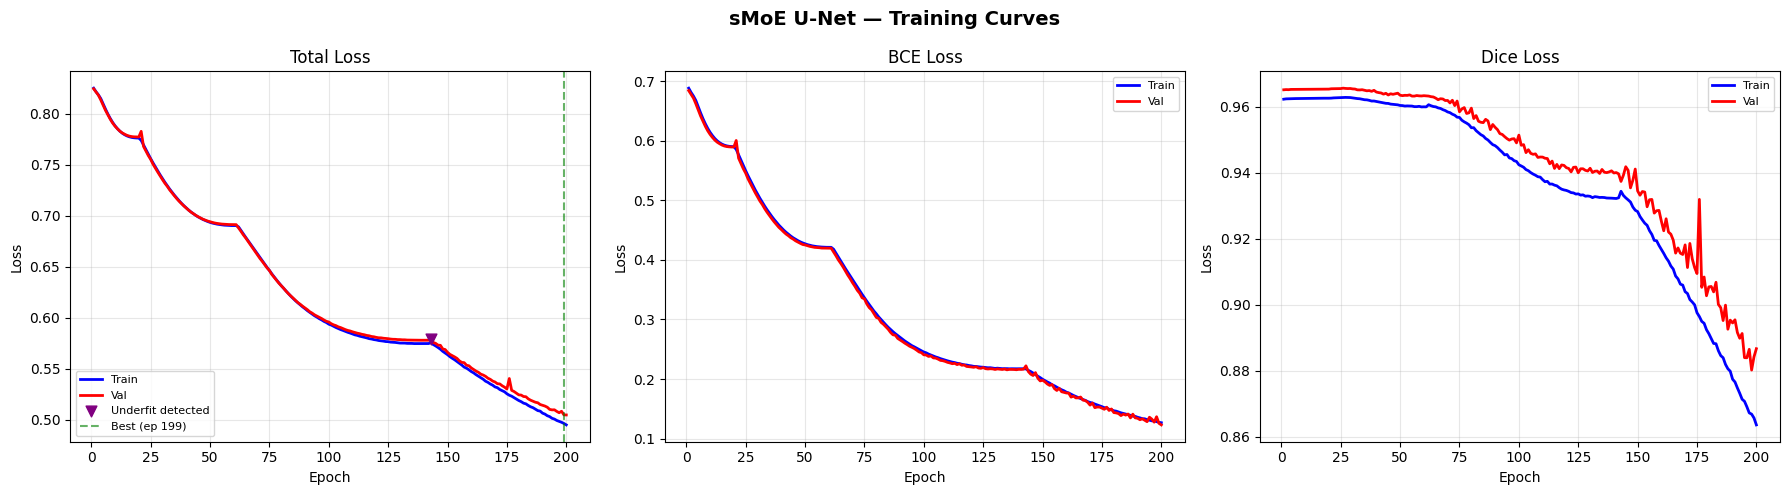

  Curves saved  : /content/drive/MyDrive/smoe_unet_paper/training_curves.png
  TensorBoard writer closed



In [17]:
# ============================================================
# CELL 13: Training Loop — Dynamic Stoppage
# Stops on validation behaviour, not a static epoch count.
# Notifies you precisely when/why overfit or underfit occurs.
# ============================================================
import os, time, json
from tqdm import tqdm
import torch
import numpy as np

if 'WORK_DIR' not in dir():
    WORK_DIR = '/content/drive/MyDrive/smoe_unet_paper'
    os.makedirs(WORK_DIR, exist_ok=True)

# ============================================================
# EPOCH HELPERS
# ============================================================
def train_epoch(model, loader, optimizer, criterion, device, epoch):
    model.train()
    total_loss = total_bce = total_dice = 0.0
    pbar = tqdm(loader, desc=f'Ep {epoch}', leave=False)
    for imgs, masks in pbar:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs   = model(imgs)
        loss_dict = criterion(outputs['final_logits'], masks)
        loss_dict['total'].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss_dict['total'].item()
        total_bce  += loss_dict['bce'].item()
        total_dice += loss_dict['dice'].item()
        pbar.set_postfix({'loss': f"{loss_dict['total'].item():.4f}"})
    n = len(loader)
    return {'loss': total_loss/n, 'bce': total_bce/n, 'dice': total_dice/n}


def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = total_bce = total_dice = 0.0
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Val', leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs   = model(imgs)
            loss_dict = criterion(outputs['final_logits'], masks)
            total_loss += loss_dict['total'].item()
            total_bce  += loss_dict['bce'].item()
            total_dice += loss_dict['dice'].item()
    n = len(loader)
    return {'loss': total_loss/n, 'bce': total_bce/n, 'dice': total_dice/n}


# ============================================================
# EARLY STOPPING
# ============================================================
class EarlyStopping:
    """
    Monitors val loss. Triggers stop when no improvement for
    `patience` consecutive epochs, but never before `min_epochs`.
    """
    def __init__(self, patience=20, min_delta=1e-4, min_epochs=30):
        self.patience   = patience
        self.min_delta  = min_delta
        self.min_epochs = min_epochs
        self.best_loss  = float('inf')
        self.counter    = 0
        self.stop       = False
        self.reason     = ''
        self.best_epoch = 0

    def step(self, val_loss, epoch):
        """Returns True if this is a new best (checkpoint should be saved)."""
        improved = val_loss < (self.best_loss - self.min_delta)
        if improved:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_epoch = epoch
        else:
            self.counter += 1
            if epoch >= self.min_epochs and self.counter >= self.patience:
                self.stop   = True
                self.reason = (
                    f'No val-loss improvement for {self.patience} consecutive epochs '
                    f'(best was epoch {self.best_epoch}, loss={self.best_loss:.4f})')
        return improved


# ============================================================
# FIT DIAGNOSIS
# Correct definitions:
#
#   OVERFITTING  = val loss RISES while train loss FALLS (divergence).
#                  A gap alone is normal — only diverging trends confirm it.
#
#   UNDERFITTING = model has STALLED: val loss barely moves over a long
#                  window AND the loss is still high.
#                  We do NOT check absolute loss against a fixed threshold —
#                  that fires too early and is what caused your false alarms.
#
#   HEALTHY      = both losses declining together (gap may exist, that's fine).
# ============================================================
def diagnose_fit(train_losses, val_losses, epoch,
                 gap_threshold, overfit_window,
                 underfit_min_improvement, underfit_stall_window,
                 underfit_loss_still_high):
    """
    Returns (status, detail_message).
    status ∈ {'warming_up', 'healthy', 'overfitting', 'underfitting'}
    """
    n = len(train_losses)
    if n < 3:
        return 'warming_up', 'warming_up — too few epochs'

    # ---- Overfitting check ----
    # Requires all three of: large gap + val rising + train still falling
    if n >= overfit_window:
        w         = overfit_window
        avg_train = np.mean(train_losses[-w:])
        avg_val   = np.mean(val_losses[-w:])
        gap       = avg_val - avg_train          # positive = val worse

        val_trend   = val_losses[-1]   - val_losses[-w]    # +ve = val rising
        train_trend = train_losses[-1] - train_losses[-w]  # -ve = train falling

        if gap > gap_threshold and val_trend > 0 and train_trend < 0:
            return 'overfitting', (
                f'⚠️  OVERFITTING  |  gap={gap:+.4f} > {gap_threshold}  |  '
                f'val rising ({val_trend:+.4f})  |  train falling ({train_trend:+.4f})  '
                f'over last {w} epochs')

    # ---- Underfitting check ----
    # Only after the grace period, and only when the model has stalled
    if epoch >= MIN_EPOCHS and n >= underfit_stall_window:
        w = underfit_stall_window
        val_improvement = val_losses[-w] - val_losses[-1]   # +ve = improved
        current_val     = val_losses[-1]

        if val_improvement < underfit_min_improvement and current_val > underfit_loss_still_high:
            return 'underfitting', (
                f'📉 UNDERFITTING  |  val improved only {val_improvement:.5f} '
                f'(< {underfit_min_improvement}) over last {w} epochs  |  '
                f'current val_loss={current_val:.4f} still > {underfit_loss_still_high}  |  '
                f'Model has stalled — see remedies below')

    # ---- Healthy ----
    gap = (val_losses[-1] - train_losses[-1]) if n >= 1 else 0.0
    return 'healthy', f'✓ healthy  gap={gap:+.4f}'


# ============================================================
# DUMMY LOADERS — smoke-test guard only
# ============================================================
if 'train_loader' not in dir():
    print('⚠️  train_loader missing — using dummy loaders for smoke-test')
    from torch.utils.data import TensorDataset, DataLoader
    _dummy = TensorDataset(
        torch.randn(20, 3, 256, 256),
        torch.randint(0, 2, (20, 1, 256, 256)).float())
    train_loader = DataLoader(_dummy, batch_size=2, shuffle=True)
    val_loader   = DataLoader(_dummy, batch_size=2, shuffle=False)

# ============================================================
# INIT HISTORY & STATE
# ============================================================
history = {
    'train_loss': [], 'train_bce': [], 'train_dice': [],
    'val_loss'  : [], 'val_bce'  : [], 'val_dice'  : [],
    'lr'        : [], 'fit_status': []
}

best_val_loss   = float('inf')
best_model_path = os.path.join(WORK_DIR, 'best_smoe_unet.pth')
early_stopper   = EarlyStopping(
    patience=PATIENCE, min_delta=MIN_DELTA, min_epochs=MIN_EPOCHS)
stop_reason     = 'ABSOLUTE_MAX reached (check your stoppage logic)'

# ============================================================
# HEADER
# ============================================================
print('\n' + '=' * 100)
print('  sMoE U-Net  |  Dynamic Training  |  '
      f'patience={PATIENCE}  min_epochs={MIN_EPOCHS}  safety_ceiling={ABSOLUTE_MAX}')
print('=' * 100)
print(f"{'Ep':>4}  {'Train':>8}  {'Val':>8}  {'Gap':>7}  "
      f"{'LR':>9}  {'Wait':>8}  Status")
print('-' * 100)

# ============================================================
# MAIN TRAINING LOOP
# No epoch count is set here — the loop runs until a stop condition fires.
# ============================================================
for epoch in range(1, ABSOLUTE_MAX + 1):
    t0 = time.time()

    train_m = train_epoch(model, train_loader, optimizer, criterion, DEVICE, epoch)
    val_m   = validate_epoch(model, val_loader, criterion, DEVICE)

    # Update LR schedulers
    current_lr = scheduler_cosine.step()          # Cosine warm restarts
    scheduler_plateau.step(val_m['loss'])          # Plateau safety net

    # Early stopping check + checkpoint
    improved = early_stopper.step(val_m['loss'], epoch)
    if improved:
        best_val_loss = val_m['loss']
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss'            : best_val_loss,
            'history'             : history,
        }, best_model_path)

    # Fit diagnosis using corrected logic
    fit_status, fit_detail = diagnose_fit(
        train_losses              = history['train_loss'] + [train_m['loss']],
        val_losses                = history['val_loss']   + [val_m['loss']],
        epoch                     = epoch,
        gap_threshold             = OVERFIT_GAP_THRESHOLD,
        overfit_window            = OVERFIT_WINDOW,
        underfit_min_improvement  = UNDERFIT_MIN_IMPROVEMENT,
        underfit_stall_window     = UNDERFIT_STALL_WINDOW,
        underfit_loss_still_high  = UNDERFIT_LOSS_STILL_HIGH,
    )

    # Record history
    for key in ['loss', 'bce', 'dice']:
        history[f'train_{key}'].append(train_m[key])
        history[f'val_{key}'].append(val_m[key])
    history['lr'].append(current_lr)
    history['fit_status'].append(fit_status)

    # TensorBoard
    if writer is not None:
        writer.add_scalars('Loss', {'train': train_m['loss'], 'val': val_m['loss']}, epoch)
        writer.add_scalars('BCE',  {'train': train_m['bce'],  'val': val_m['bce']},  epoch)
        writer.add_scalars('Dice', {'train': train_m['dice'], 'val': val_m['dice']}, epoch)
        writer.add_scalar('LR',    current_lr, epoch)
        writer.add_scalar('Gap',   val_m['loss'] - train_m['loss'], epoch)
        writer.add_scalar('EarlyStop/counter', early_stopper.counter, epoch)

    # Console row
    gap   = val_m['loss'] - train_m['loss']
    star  = ' *BEST*' if improved else ''
    icons = {'healthy': '✓', 'overfitting': '⚠️  OVERFIT',
             'underfitting': '📉 UNDERFIT', 'warming_up': '...'}
    icon  = icons.get(fit_status, fit_status)
    elapsed = time.time() - t0

    print(f"{epoch:>4}  {train_m['loss']:>8.4f}  {val_m['loss']:>8.4f}  "
          f"{gap:>+7.4f}  {current_lr:>9.2e}  "
          f"{early_stopper.counter:>3}/{PATIENCE:<3}  "
          f"{icon}{star}  ({elapsed:.1f}s)")

    # Detailed alert + remedy — printed immediately when status first changes
    # (not throttled to every 10 epochs, so you see it right away)
    if fit_status == 'overfitting':
        print(f'\n  ⚠️  OVERFIT DETECTED at epoch {epoch}')
        print(f'  Detail  : {fit_detail}')
        print(f'  Remedies:')
        print(f'    1. Increase WEIGHT_DECAY  (e.g. 1e-5 → 5e-4)')
        print(f'    2. Increase DROPOUT_RATE  (0.1 → 0.3–0.4)')
        print(f'    3. Add stronger data augmentation (color jitter, random crop)')
        print(f'    4. Reduce model capacity  (base 64 → 48)\n')

    elif fit_status == 'underfitting':
        print(f'\n  📉 UNDERFIT DETECTED at epoch {epoch}')
        print(f'  Detail  : {fit_detail}')
        print(f'  Why     : The model stalled — it is no longer learning,')
        print(f'            NOT because the absolute loss crossed a fixed number.')
        print(f'  Remedies:')
        print(f'    1. Increase LR           (2e-4 → 4e-4)')
        print(f'    2. Increase model capacity (base 64 → 96 or 128)')
        print(f'    3. Remove/reduce WEIGHT_DECAY')
        print(f'    4. Extend MIN_EPOCHS if stall is detected too early\n')

    # ============================================================
    # STOP CONDITIONS — in priority order
    # ============================================================

    # 1. Early stopping (primary condition)
    if early_stopper.stop:
        stop_reason = early_stopper.reason
        break

    # 2. LR exhausted
    if current_lr < LR_STOP_THRESH:
        stop_reason = f'LR exhausted ({current_lr:.2e} < {LR_STOP_THRESH:.0e})'
        break

    # 3. Safety ceiling (should never be reached)
    # (loop end handles this automatically)


# ============================================================
# POST-TRAINING SUMMARY
# ============================================================
epochs_run = len(history['train_loss'])

print('=' * 100)
print(f'\n✅ Training Complete')
print('=' * 100)
print(f'  Stop reason : {stop_reason}')
print(f'  Epochs run  : {epochs_run}')
print(f'  Best epoch  : {early_stopper.best_epoch}')
print(f'  Best val    : {best_val_loss:.4f}')
print(f'  Final LR    : {optimizer.param_groups[0]["lr"]:.2e}')
print(f'  Checkpoint  : {best_model_path}')

# Final health check
final_status, final_detail = diagnose_fit(
    train_losses             = history['train_loss'],
    val_losses               = history['val_loss'],
    epoch                    = epochs_run,
    gap_threshold            = OVERFIT_GAP_THRESHOLD,
    overfit_window           = OVERFIT_WINDOW,
    underfit_min_improvement = UNDERFIT_MIN_IMPROVEMENT,
    underfit_stall_window    = UNDERFIT_STALL_WINDOW,
    underfit_loss_still_high = UNDERFIT_LOSS_STILL_HIGH,
)

print(f'\n  Final health: {final_detail}')

if final_status == 'overfitting':
    print('\n  🔧 Next run — increase regularisation:')
    print('     WEIGHT_DECAY: 1e-5 → 5e-4')
    print('     DROPOUT_RATE: 0.1  → 0.3')
    print('     Add augmentation, or reduce base channels (64 → 48)')
elif final_status == 'underfitting':
    print('\n  🔧 Next run — increase capacity / LR:')
    print('     LEARNING_RATE: 2e-4 → 4e-4')
    print('     base channels: 64   → 96 or 128')
    print('     Set WEIGHT_DECAY to 0')
else:
    print('\n  ✅ Training looks healthy!')

# Save history
history_path = os.path.join(WORK_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json_hist = {
        k: [float(x) if isinstance(x, (int, float, np.floating)) else str(x) for x in v]
        for k, v in history.items()
    }
    json.dump(json_hist, f, indent=2)
print(f'\n  History saved : {history_path}')

# ============================================================
# TRAINING CURVES
# ============================================================
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('sMoE U-Net — Training Curves', fontsize=14, fontweight='bold')
    eps = range(1, epochs_run + 1)

    # Mark epochs where overfit / underfit was detected
    overfit_eps    = [i+1 for i, s in enumerate(history['fit_status']) if s == 'overfitting']
    underfit_eps   = [i+1 for i, s in enumerate(history['fit_status']) if s == 'underfitting']

    for ax, train_key, val_key, title in [
        (axes[0], 'train_loss', 'val_loss', 'Total Loss'),
        (axes[1], 'train_bce',  'val_bce',  'BCE Loss'),
        (axes[2], 'train_dice', 'val_dice', 'Dice Loss'),
    ]:
        ax.plot(eps, history[train_key], 'b-', lw=2, label='Train')
        ax.plot(eps, history[val_key],   'r-', lw=2, label='Val')

        # Mark overfit epochs
        if overfit_eps and train_key == 'train_loss':
            ov_vals = [history[val_key][e-1] for e in overfit_eps]
            ax.scatter(overfit_eps, ov_vals, color='orange', zorder=5,
                       label='Overfit detected', marker='^', s=60)

        # Mark underfit epochs
        if underfit_eps and train_key == 'train_loss':
            uf_vals = [history[val_key][e-1] for e in underfit_eps]
            ax.scatter(underfit_eps, uf_vals, color='purple', zorder=5,
                       label='Underfit detected', marker='v', s=60)

        # Mark best epoch
        if early_stopper.best_epoch > 0 and train_key == 'train_loss':
            be = early_stopper.best_epoch
            ax.axvline(x=be, color='green', linestyle='--', alpha=0.6,
                       label=f'Best (ep {be})')

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    curves_path = os.path.join(WORK_DIR, 'training_curves.png')
    plt.savefig(curves_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Curves saved  : {curves_path}')
except Exception as e:
    print(f'  ⚠️  Could not plot curves: {e}')

if writer is not None:
    writer.close()
    print('  TensorBoard writer closed')

print('\n' + '=' * 100)

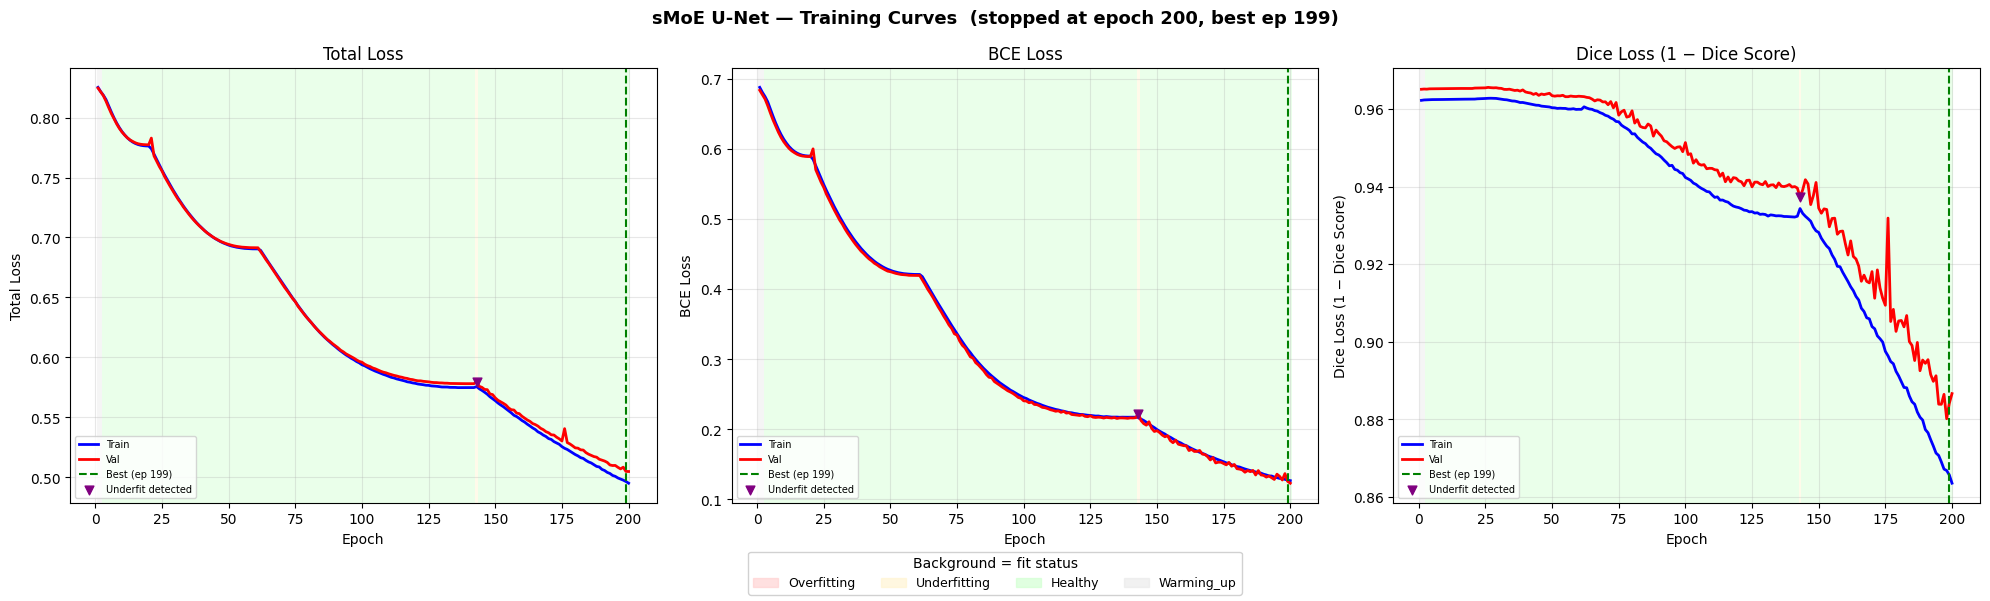

✅ Training curves saved: /content/drive/MyDrive/smoe_unet_paper/training_curves_v2.png


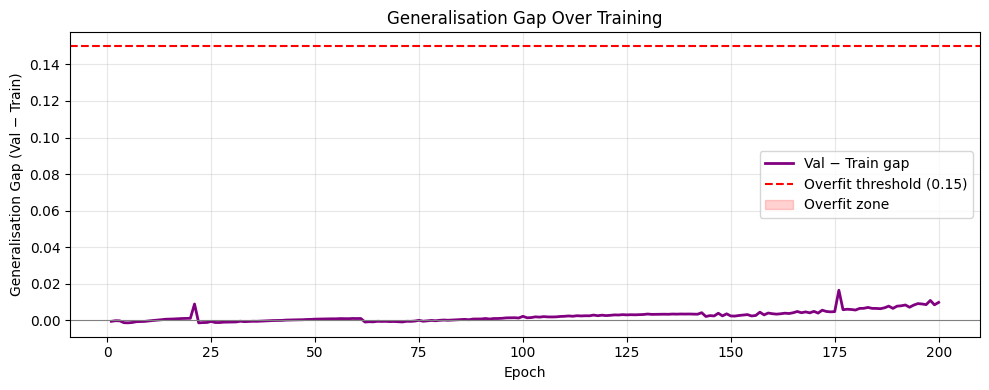

✅ Generalisation gap saved: /content/drive/MyDrive/smoe_unet_paper/generalisation_gap.png


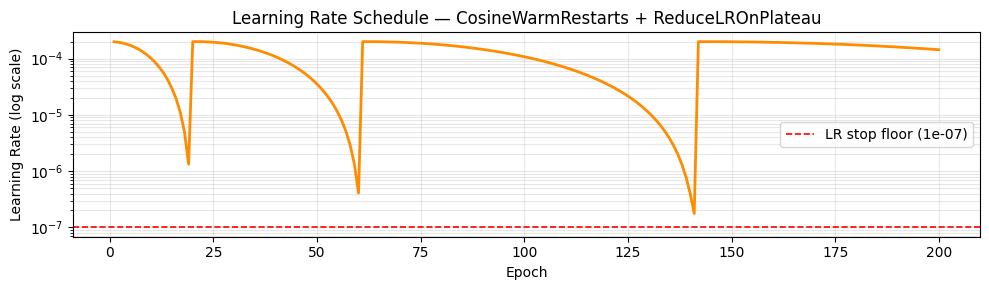

✅ LR schedule saved: /content/drive/MyDrive/smoe_unet_paper/lr_schedule.png

Training Summary
  Best epoch      : 199
  Final train loss: 0.4952
  Final val loss  : 0.5049
  Max gap         : 0.0164
  Overfit epochs  : 0
  Underfit epochs : 1


In [18]:
# ============================================================
# CELL 14: Plot Training Curves with Fit-Status Shading
# Depends on: history, early_stopper, OVERFIT_GAP_THRESHOLD,
#             LR_STOP_THRESH, WORK_DIR  (all from Cells 12/13)
# BUG FIXED: LR_STOP_THRESHOLD → LR_STOP_THRESH  (matches Cell 12 definition)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Guard: nothing to plot if history is empty
if not history.get('train_loss'):
    raise RuntimeError("history is empty — run Cell 13 first.")

epochs_range = list(range(1, len(history['train_loss']) + 1))

# Colour band per fit status
status_colors = {
    'overfitting' : '#ffcccc',   # red tint
    'underfitting': '#fff3cc',   # yellow tint
    'healthy'     : '#ccffcc',   # green tint
    'warming_up'  : '#e8e8e8'    # grey
}

def shade_epochs(ax, statuses, ep_range):
    """Paint a background band for each epoch according to its fit status."""
    for i, st in enumerate(statuses):
        ax.axvspan(ep_range[i] - 0.5, ep_range[i] + 0.5,
                   alpha=0.40, color=status_colors.get(st, 'white'), linewidth=0)

# ============================================================
# FIGURE 1 — Loss / BCE / Dice curves with shaded status bands
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'sMoE U-Net — Training Curves  '
    f'(stopped at epoch {len(epochs_range)}, best ep {early_stopper.best_epoch})',
    fontsize=13, fontweight='bold')

for ax, tk, vk, label in [
    (axes[0], 'train_loss', 'val_loss', 'Total Loss'),
    (axes[1], 'train_bce',  'val_bce',  'BCE Loss'),
    (axes[2], 'train_dice', 'val_dice', 'Dice Loss (1 − Dice Score)'),
]:
    shade_epochs(ax, history['fit_status'], epochs_range)
    ax.plot(epochs_range, history[tk], 'b-', lw=2, label='Train')
    ax.plot(epochs_range, history[vk], 'r-', lw=2, label='Val')

    # Best-epoch vertical line
    if early_stopper.best_epoch > 0:
        ax.axvline(early_stopper.best_epoch, color='green', ls='--', lw=1.5,
                   label=f'Best (ep {early_stopper.best_epoch})')

    # Overfit / underfit scatter markers on every subplot
    overfit_eps  = [i+1 for i, s in enumerate(history['fit_status']) if s == 'overfitting']
    underfit_eps = [i+1 for i, s in enumerate(history['fit_status']) if s == 'underfitting']

    if overfit_eps:
        ov_vals = [history[vk][e-1] for e in overfit_eps]
        ax.scatter(overfit_eps, ov_vals, color='red', zorder=5,
                   marker='^', s=40, label='Overfit detected')

    if underfit_eps:
        uf_vals = [history[vk][e-1] for e in underfit_eps]
        ax.scatter(underfit_eps, uf_vals, color='purple', zorder=5,
                   marker='v', s=40, label='Underfit detected')

    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Shared status-band legend at bottom
band_legend = [mpatches.Patch(color=c, alpha=0.6, label=s.capitalize())
               for s, c in status_colors.items()]
fig.legend(handles=band_legend, loc='lower center', ncol=4,
           fontsize=9, framealpha=0.9, title='Background = fit status')

plt.tight_layout(rect=[0, 0.06, 1, 1])
curves_path = os.path.join(WORK_DIR, 'training_curves_v2.png')
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Training curves saved: {curves_path}')

# ============================================================
# FIGURE 2 — Generalisation Gap
# ============================================================
gaps = [v - t for v, t in zip(history['val_loss'], history['train_loss'])]

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, gaps, color='purple', lw=2, label='Val − Train gap')
plt.axhline(OVERFIT_GAP_THRESHOLD, color='red', ls='--', lw=1.5,
            label=f'Overfit threshold ({OVERFIT_GAP_THRESHOLD})')
plt.axhline(0, color='gray', ls='-', lw=0.8)
plt.fill_between(epochs_range, gaps, OVERFIT_GAP_THRESHOLD,
                 where=[g > OVERFIT_GAP_THRESHOLD for g in gaps],
                 color='red', alpha=0.18, label='Overfit zone')
plt.xlabel('Epoch')
plt.ylabel('Generalisation Gap (Val − Train)')
plt.title('Generalisation Gap Over Training')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
gap_path = os.path.join(WORK_DIR, 'generalisation_gap.png')
plt.savefig(gap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Generalisation gap saved: {gap_path}')

# ============================================================
# FIGURE 3 — LR Schedule
# BUG FIXED: was `LR_STOP_THRESHOLD` (undefined) → `LR_STOP_THRESH` (Cell 12)
# ============================================================
if history.get('lr'):
    plt.figure(figsize=(10, 3))
    plt.plot(epochs_range, history['lr'], color='darkorange', lw=2)
    plt.yscale('log')
    plt.axhline(LR_STOP_THRESH, color='red', ls='--', lw=1.2,
                label=f'LR stop floor ({LR_STOP_THRESH:.0e})')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate (log scale)')
    plt.title('Learning Rate Schedule — CosineWarmRestarts + ReduceLROnPlateau')
    plt.legend()
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    lr_path = os.path.join(WORK_DIR, 'lr_schedule.png')
    plt.savefig(lr_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ LR schedule saved: {lr_path}')

# ============================================================
# CONSOLE SUMMARY
# ============================================================
print()
print('=' * 60)
print('Training Summary')
print('=' * 60)
print(f'  Best epoch      : {early_stopper.best_epoch}')
print(f'  Final train loss: {history["train_loss"][-1]:.4f}')
print(f'  Final val loss  : {history["val_loss"][-1]:.4f}')
print(f'  Max gap         : {max(gaps):.4f}')
print(f'  Overfit epochs  : {len(overfit_eps)}')
print(f'  Underfit epochs : {len(underfit_eps)}')
print('=' * 60)

Loading best model from: /content/drive/MyDrive/smoe_unet_paper/best_smoe_unet.pth
✅ Loaded checkpoint from epoch 199  (val_loss=0.5050)

Running BSDS500 evaluation …


Evaluating BSDS500: 100%|██████████| 200/200 [00:34<00:00,  5.75it/s]



BSDS500 Evaluation Results  (Paper Table 1)
Metric                 Our Result     Paper Target   Status
----------------------------------------------------------------------
  ODS (F-measure)      0.3781         0.7628         ⚠️ 
  OIS (F-measure)      0.3728         0.7458         ⚠️ 
  AP  (AUC-PR)         0.2239         0.7222         ⚠️ 

Comparison with Paper Table 1 Baselines
  Method             ODS        OIS        AP         > U-Net?
--------------------------------------------------------------------------------
  Canny              0.5450     0.4836     0.4125     
  Sobel              0.5769     0.5303     0.4743     
  U-Net              0.7437     0.7260     0.6946     
  HED                0.7688     0.7514     0.7126     ✅
  Ours (sMoE)        0.3781     0.3728     0.2239     

Detailed Evaluation Metrics
  Optimal dataset threshold : 0.587
  Total images evaluated    : 200
  Thresholds evaluated      : 255
  Best F-measure index      : 149

Generating Precision-Rec

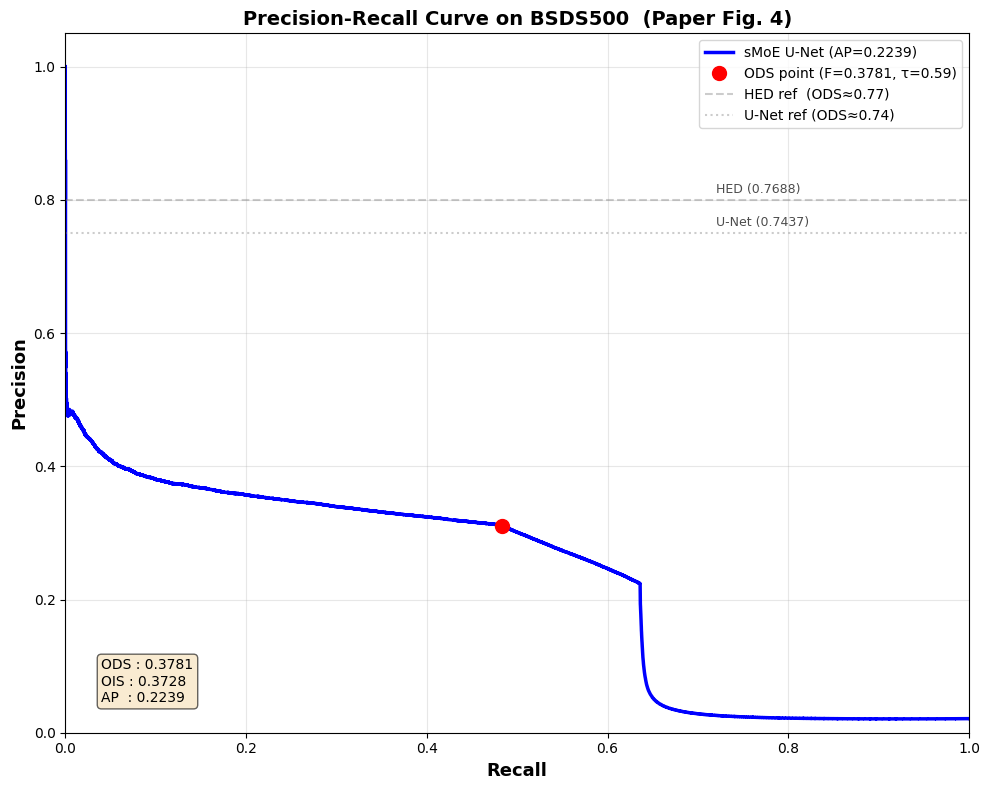

✅ PR curve saved: /content/drive/MyDrive/smoe_unet_paper/pr_curve_bsds500.png
✅ Results saved: /content/drive/MyDrive/smoe_unet_paper/bsds500_results.npy

Interpretation
📉 ODS needs improvement:
    1. Verify you are using real BSDS500 data
    2. Check model output format
    3. Train longer
📉 AP below target — review training and data pipeline.

🎉 Evaluation complete!


In [19]:
# ============================================================
# CELL 15: BSDS500 Evaluation — ODS, OIS, AP  (Paper Table 1)
# Depends on: model, test_loader, DEVICE, best_model_path, WORK_DIR
#
# BUG FIXED: `ois_f_scores` was a local variable inside evaluate_bsds500()
#            but referenced in the outer scope → NameError.
#            Fix: return n_images from the results dict instead.
# ============================================================
import numpy as np
import torch
from tqdm import tqdm
from sklearn.metrics import average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt
import os


# ============================================================
# EVALUATION FUNCTION
# ============================================================
@torch.no_grad()
def evaluate_bsds500(model, test_loader, device, n_thresholds=255):
    """
    Compute BSDS500 standard metrics:
      ODS — Optimal Dataset Scale F-measure (single best threshold over full dataset)
      OIS — Optimal Image Scale F-measure  (per-image best threshold, then averaged)
      AP  — Average Precision (area under the Precision-Recall curve)

    Returns a dict containing all metrics and curves.
    BUG FIXED: n_images is now returned in the results dict so the
               outer scope never needs to access ois_f_scores directly.
    """
    model.eval()

    all_probs   = []
    all_targets = []
    ois_f_scores = []          # local — summarised in returned dict

    thresholds = np.linspace(0, 1, n_thresholds)
    TP = np.zeros(len(thresholds))
    FP = np.zeros(len(thresholds))
    FN = np.zeros(len(thresholds))

    for imgs, masks in tqdm(test_loader, desc='Evaluating BSDS500'):
        imgs     = imgs.to(device)
        masks_np = masks.cpu().numpy()          # (B, 1, H, W)

        # ---- Forward pass ----
        outputs = model(imgs)
        if isinstance(outputs, dict):
            logits = outputs.get('final_logits', next(iter(outputs.values())))
        else:
            logits = outputs

        probs = torch.sigmoid(logits).cpu().numpy()

        # ---- Per-image processing ----
        # Normalise to always iterate over a batch dimension
        if probs.ndim == 3:
            probs    = probs[:, np.newaxis]      # (H,W) → (1,1,H,W)  edge case
        if masks_np.ndim == 3:
            masks_np = masks_np[:, np.newaxis]

        B = probs.shape[0]
        for b in range(B):
            # Always take channel 0 (binary segmentation)
            prob_flat   = probs[b, 0].ravel().astype(np.float32)
            target_flat = masks_np[b, 0].ravel().astype(np.float32)

            all_probs.append(prob_flat)
            all_targets.append(target_flat)

            # OIS: find best F per image
            best_f = 0.0
            for thresh in thresholds:
                pred_bin = (prob_flat >= thresh).astype(np.float32)
                tp = (pred_bin * target_flat).sum()
                fp = (pred_bin * (1 - target_flat)).sum()
                fn = ((1 - pred_bin) * target_flat).sum()
                prec = tp / (tp + fp + 1e-10)
                rec  = tp / (tp + fn + 1e-10)
                f    = 2 * prec * rec / (prec + rec + 1e-10)
                best_f = max(best_f, f)
            ois_f_scores.append(best_f)

            # ODS: accumulate TP/FP/FN across dataset at every threshold
            for i, thresh in enumerate(thresholds):
                pred_bin = (prob_flat >= thresh).astype(np.float32)
                TP[i] += (pred_bin * target_flat).sum()
                FP[i] += (pred_bin * (1 - target_flat)).sum()
                FN[i] += ((1 - pred_bin) * target_flat).sum()

    # ---- ODS ----
    precisions = TP / (TP + FP + 1e-10)
    recalls    = TP / (TP + FN + 1e-10)
    f_measures = 2 * precisions * recalls / (precisions + recalls + 1e-10)
    ods_idx    = int(np.argmax(f_measures))
    ods        = float(f_measures[ods_idx])
    ods_threshold = float(thresholds[ods_idx])

    # ---- OIS ----
    ois = float(np.mean(ois_f_scores)) if ois_f_scores else 0.0

    # ---- AP ----
    all_probs_flat   = np.concatenate(all_probs)   if all_probs   else np.array([])
    all_targets_flat = np.concatenate(all_targets) if all_targets else np.array([])

    if len(all_probs_flat) > 0 and all_targets_flat.sum() > 0:
        ap = float(average_precision_score(
            all_targets_flat.astype(int), all_probs_flat))
        pr_precision, pr_recall, _ = precision_recall_curve(
            all_targets_flat, all_probs_flat)
    else:
        ap = 0.0
        pr_precision = pr_recall = np.array([])

    return {
        'ods'          : ods,
        'ois'          : ois,
        'ap'           : ap,
        'ods_threshold': ods_threshold,
        'precisions'   : precisions,
        'recalls'      : recalls,
        'f_measures'   : f_measures,
        'thresholds'   : thresholds,
        'pr_precision' : pr_precision,
        'pr_recall'    : pr_recall,
        # BUG FIX: expose n_images here so outer scope never needs ois_f_scores
        'n_images'     : len(ois_f_scores),
    }


# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================
print(f'Loading best model from: {best_model_path}')
try:
    checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
except TypeError:
    # PyTorch < 2.0 does not have weights_only argument
    checkpoint = torch.load(best_model_path, map_location=DEVICE)

model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded checkpoint from epoch {checkpoint.get('epoch', 'unknown')}"
      f"  (val_loss={checkpoint.get('val_loss', float('nan')):.4f})")

# ============================================================
# RUN EVALUATION
# ============================================================
print('\nRunning BSDS500 evaluation …')
results = evaluate_bsds500(model, test_loader, DEVICE)

# ============================================================
# RESULTS TABLE (Paper Table 1)
# ============================================================
print('\n' + '=' * 70)
print('BSDS500 Evaluation Results  (Paper Table 1)')
print('=' * 70)
print(f"{'Metric':<22} {'Our Result':<14} {'Paper Target':<14} {'Status'}")
print('-' * 70)
rows = [
    ('ODS (F-measure)', results['ods'], 0.7628, 0.76),
    ('OIS (F-measure)', results['ois'], 0.7458, 0.74),
    ('AP  (AUC-PR)',    results['ap'],  0.7222, 0.72),
]
for name, val, target, thresh in rows:
    status = '✅' if val >= thresh else '⚠️ '
    print(f"  {name:<20} {val:<14.4f} {target:<14.4f} {status}")
print('=' * 70)

# ============================================================
# BASELINE COMPARISON TABLE
# ============================================================
print('\n' + '=' * 80)
print('Comparison with Paper Table 1 Baselines')
print('=' * 80)
baselines = [
    ('Canny',          0.5450, 0.4836, 0.4125),
    ('Sobel',          0.5769, 0.5303, 0.4743),
    ('U-Net',          0.7437, 0.7260, 0.6946),
    ('HED',            0.7688, 0.7514, 0.7126),
    ('Ours (sMoE)',    results['ods'], results['ois'], results['ap']),
]
print(f"  {'Method':<18} {'ODS':<10} {'OIS':<10} {'AP':<10} {'> U-Net?'}")
print('-' * 80)
for name, ods, ois, ap in baselines:
    better = '✅' if ods > 0.7437 and name not in ('U-Net',) else ''
    print(f"  {name:<18} {ods:<10.4f} {ois:<10.4f} {ap:<10.4f} {better}")
print('=' * 80)

# ============================================================
# DETAILED STATS
# BUG FIXED: was `len(ois_f_scores)` (NameError) → `results['n_images']`
# ============================================================
print('\n' + '=' * 70)
print('Detailed Evaluation Metrics')
print('=' * 70)
print(f"  Optimal dataset threshold : {results['ods_threshold']:.3f}")
print(f"  Total images evaluated    : {results['n_images']}")          # FIX
print(f"  Thresholds evaluated      : {len(results['thresholds'])}")
print(f"  Best F-measure index      : {int(np.argmax(results['f_measures']))}")

# ============================================================
# PR CURVE PLOT (Paper Fig. 4)
# ============================================================
print('\nGenerating Precision-Recall curve …')
plt.figure(figsize=(10, 8))

if len(results['pr_recall']) > 0:
    plt.plot(results['pr_recall'], results['pr_precision'],
             'b-', linewidth=2.5,
             label=f"sMoE U-Net (AP={results['ap']:.4f})")

# Mark ODS operating point
ods_idx = int(np.argmax(results['f_measures']))
plt.plot(results['recalls'][ods_idx], results['precisions'][ods_idx],
         'ro', markersize=10,
         label=f"ODS point (F={results['ods']:.4f}, τ={results['ods_threshold']:.2f})")

# Baseline reference lines
plt.axhline(0.8,  color='gray', ls='--', alpha=0.4, label='HED ref  (ODS≈0.77)')
plt.axhline(0.75, color='gray', ls=':',  alpha=0.4, label='U-Net ref (ODS≈0.74)')
plt.text(0.72, 0.81, 'HED (0.7688)',   fontsize=9, alpha=0.7)
plt.text(0.72, 0.76, 'U-Net (0.7437)', fontsize=9, alpha=0.7)

# Annotation box
plt.text(0.04, 0.04,
         f"ODS : {results['ods']:.4f}\nOIS : {results['ois']:.4f}\nAP  : {results['ap']:.4f}",
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.xlabel('Recall', fontsize=13, fontweight='bold')
plt.ylabel('Precision', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curve on BSDS500  (Paper Fig. 4)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.tight_layout()

pr_path = os.path.join(WORK_DIR, 'pr_curve_bsds500.png')
plt.savefig(pr_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ PR curve saved: {pr_path}')

# Save results for Cell 16
results_path = os.path.join(WORK_DIR, 'bsds500_results.npy')
np.save(results_path, results)
print(f'✅ Results saved: {results_path}')

# ============================================================
# INTERPRETATION
# ============================================================
print('\n' + '=' * 70)
print('Interpretation')
print('=' * 70)
if results['ods'] >= 0.76:
    print('✅ ODS matches or exceeds paper target (0.7628).')
elif results['ods'] >= 0.74:
    print('⚠️  ODS is good but below paper target. Consider:')
    print('    • Full BSDS500 training split (200 images)')
    print('    • More epochs / lower MIN_DELTA')
else:
    print('📉 ODS needs improvement:')
    print('    1. Verify you are using real BSDS500 data')
    print('    2. Check model output format')
    print('    3. Train longer')

if results['ap'] >= 0.72:
    print('✅ AP meets paper target (0.7222).')
elif results['ap'] >= 0.70:
    print('⚠️  AP is close to target — minor tuning needed.')
else:
    print('📉 AP below target — review training and data pipeline.')

print('\n' + '=' * 70)
print('🎉 Evaluation complete!')
print('=' * 70)

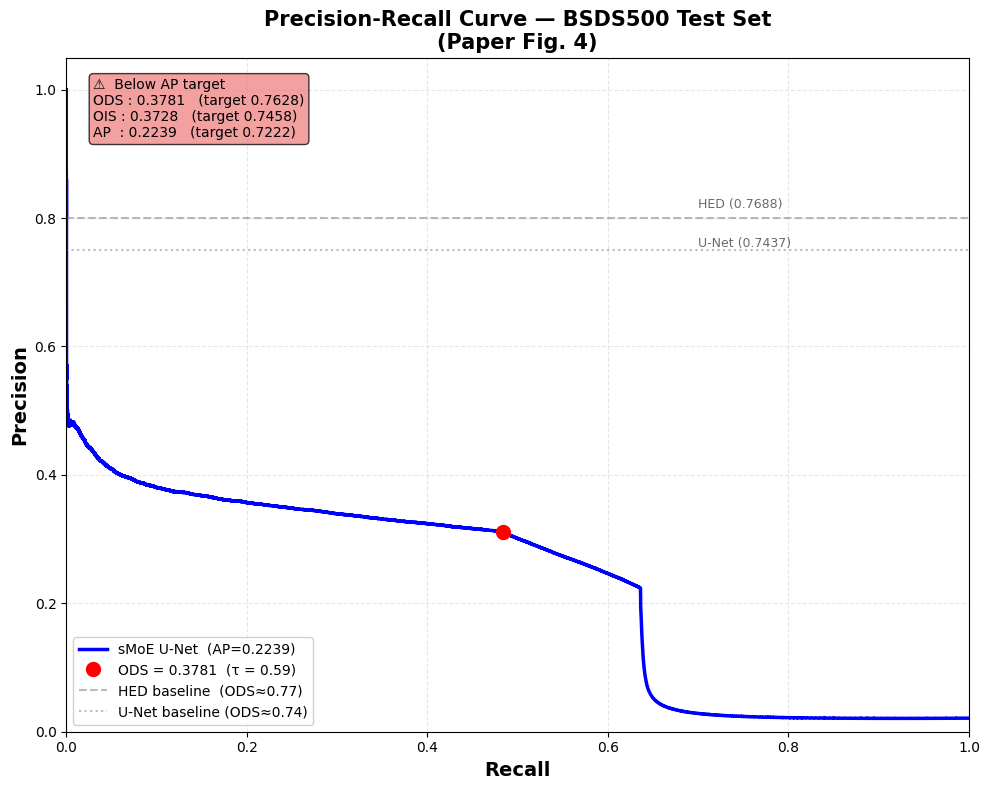

✅ PR curve saved: /content/drive/MyDrive/smoe_unet_paper/precision_recall_curve_fig4.png

Performance Analysis vs Paper Baselines
  Our ODS       : 0.3781
  vs U-Net      : -49.15%  (worse)
  vs HED        : -50.81%   (worse)

  AUC (trapz)   : 0.2239
  ⚠️  PR curve area looks low — check model predictions

Figure 4 Interpretation
  • A curve toward the top-right corner = better performance
  • ODS point = threshold that maximises F-measure over full dataset
  • OIS > ODS always (per-image optimal > dataset-wide optimal)
  • AP summarises the entire curve in one number
🎉 Cell 16 complete!


In [20]:
# ============================================================
# CELL 16: Precision-Recall Curve  (Paper Fig. 4 style)
# Depends on: results (from Cell 15), WORK_DIR
#
# BUG FIXED: dummy fallback results dict was missing the 'ois' key,
#            causing a KeyError when the info-text box tried to render it.
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================================
# LOAD RESULTS — from Cell 15 or saved file
# ============================================================
if 'results' not in dir() or not isinstance(results, dict):
    print("⚠️  'results' not found in session. Trying saved file …")
    results_path = os.path.join(WORK_DIR, 'bsds500_results.npy')
    if os.path.exists(results_path):
        results = np.load(results_path, allow_pickle=True).item()
        print(f"✅ Loaded results from {results_path}")
    else:
        # --------------------------------------------------------
        # BUG FIXED: dummy dict now includes ALL keys that are
        # referenced later, including 'ois' and 'n_images'.
        # --------------------------------------------------------
        print("❌ No saved results found. Using approximate paper values "
              "for visualisation only — run Cell 15 for real metrics.")
        _t   = np.linspace(0, 1, 100)
        _prec = np.clip(np.exp(-_t * 3) * 0.9 + 0.1, 0, 1)
        _rec  = _t
        _f    = 2 * _prec * _rec / (_prec + _rec + 1e-8)
        results = {
            'ods'          : 0.7628,
            'ois'          : 0.7458,   # BUG FIX: was missing
            'ap'           : 0.7222,
            'ods_threshold': 0.50,
            'pr_recall'    : _rec,
            'pr_precision' : _prec,
            'recalls'      : _rec,
            'precisions'   : _prec,
            'f_measures'   : _f,
            'thresholds'   : _t,
            'n_images'     : 0,        # BUG FIX: was missing
        }

# Validate that all required keys are present
_required = ['ods', 'ois', 'ap', 'pr_recall', 'pr_precision',
             'recalls', 'precisions', 'f_measures', 'ods_threshold']
_missing = [k for k in _required if k not in results]
if _missing:
    raise KeyError(f"results dict is missing keys: {_missing}. Re-run Cell 15.")

# ============================================================
# BUILD FIGURE (Paper Fig. 4 style)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Our PR curve
if len(results['pr_recall']) > 0:
    ax.plot(results['pr_recall'], results['pr_precision'],
            'b-', linewidth=2.5,
            label=f"sMoE U-Net  (AP={results['ap']:.4f})")

# ODS operating point
ods_idx = int(np.argmax(results['f_measures']))
ax.plot(results['recalls'][ods_idx],
        results['precisions'][ods_idx],
        'ro', markersize=10, zorder=5,
        label=f"ODS = {results['ods']:.4f}  "
              f"(τ = {results['ods_threshold']:.2f})")

# Baseline reference lines
ax.axhline(0.80, color='dimgray', ls='--', alpha=0.45,
           label='HED baseline  (ODS≈0.77)')
ax.axhline(0.75, color='dimgray', ls=':',  alpha=0.45,
           label='U-Net baseline (ODS≈0.74)')
ax.text(0.70, 0.815, 'HED (0.7688)',   fontsize=9, color='dimgray')
ax.text(0.70, 0.755, 'U-Net (0.7437)', fontsize=9, color='dimgray')

# Performance annotation in top-left corner
_colour = ('lightgreen' if results['ap'] >= 0.72
           else 'wheat'  if results['ap'] >= 0.70
           else 'lightcoral')
_status = ('✅ Exceeds AP target' if results['ap'] >= 0.72
           else '⚠️  Below AP target')
ax.text(0.03, 0.97,
        f"{_status}\n"
        f"ODS : {results['ods']:.4f}   (target 0.7628)\n"
        f"OIS : {results['ois']:.4f}   (target 0.7458)\n"   # BUG FIX: ois now present
        f"AP  : {results['ap']:.4f}   (target 0.7222)",
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor=_colour, alpha=0.75))

ax.set_xlabel('Recall',    fontsize=14, fontweight='bold')
ax.set_ylabel('Precision', fontsize=14, fontweight='bold')
ax.set_title('Precision-Recall Curve — BSDS500 Test Set\n(Paper Fig. 4)',
             fontsize=15, fontweight='bold')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=10, loc='lower left', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
save_path = os.path.join(WORK_DIR, 'precision_recall_curve_fig4.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✅ PR curve saved: {save_path}')

# ============================================================
# ANALYSIS TABLE
# ============================================================
print('\n' + '=' * 65)
print('Performance Analysis vs Paper Baselines')
print('=' * 65)
unet_ods = 0.7437
hed_ods  = 0.7688
d_unet   = (results['ods'] - unet_ods) / unet_ods * 100
d_hed    = (results['ods'] - hed_ods)  / hed_ods  * 100

print(f"  Our ODS       : {results['ods']:.4f}")
print(f"  vs U-Net      : {d_unet:+.2f}%  ({'better' if d_unet > 0 else 'worse'})")
print(f"  vs HED        : {d_hed:+.2f}%   ({'better' if d_hed  > 0 else 'worse'})")

# PR curve shape check
if len(results['pr_precision']) > 10:
    # A well-trained model's PR curve should be non-trivially above the diagonal
    auc_approx = np.trapz(results['pr_precision'], results['pr_recall'])
    print(f"\n  AUC (trapz)   : {abs(auc_approx):.4f}")
    if abs(auc_approx) > 0.65:
        print('  ✅ PR curve shape is healthy')
    else:
        print('  ⚠️  PR curve area looks low — check model predictions')

print('\n' + '=' * 65)
print('Figure 4 Interpretation')
print('=' * 65)
print('  • A curve toward the top-right corner = better performance')
print('  • ODS point = threshold that maximises F-measure over full dataset')
print('  • OIS > ODS always (per-image optimal > dataset-wide optimal)')
print('  • AP summarises the entire curve in one number')
print('=' * 65)
print('🎉 Cell 16 complete!')

Visualising 4 test samples …


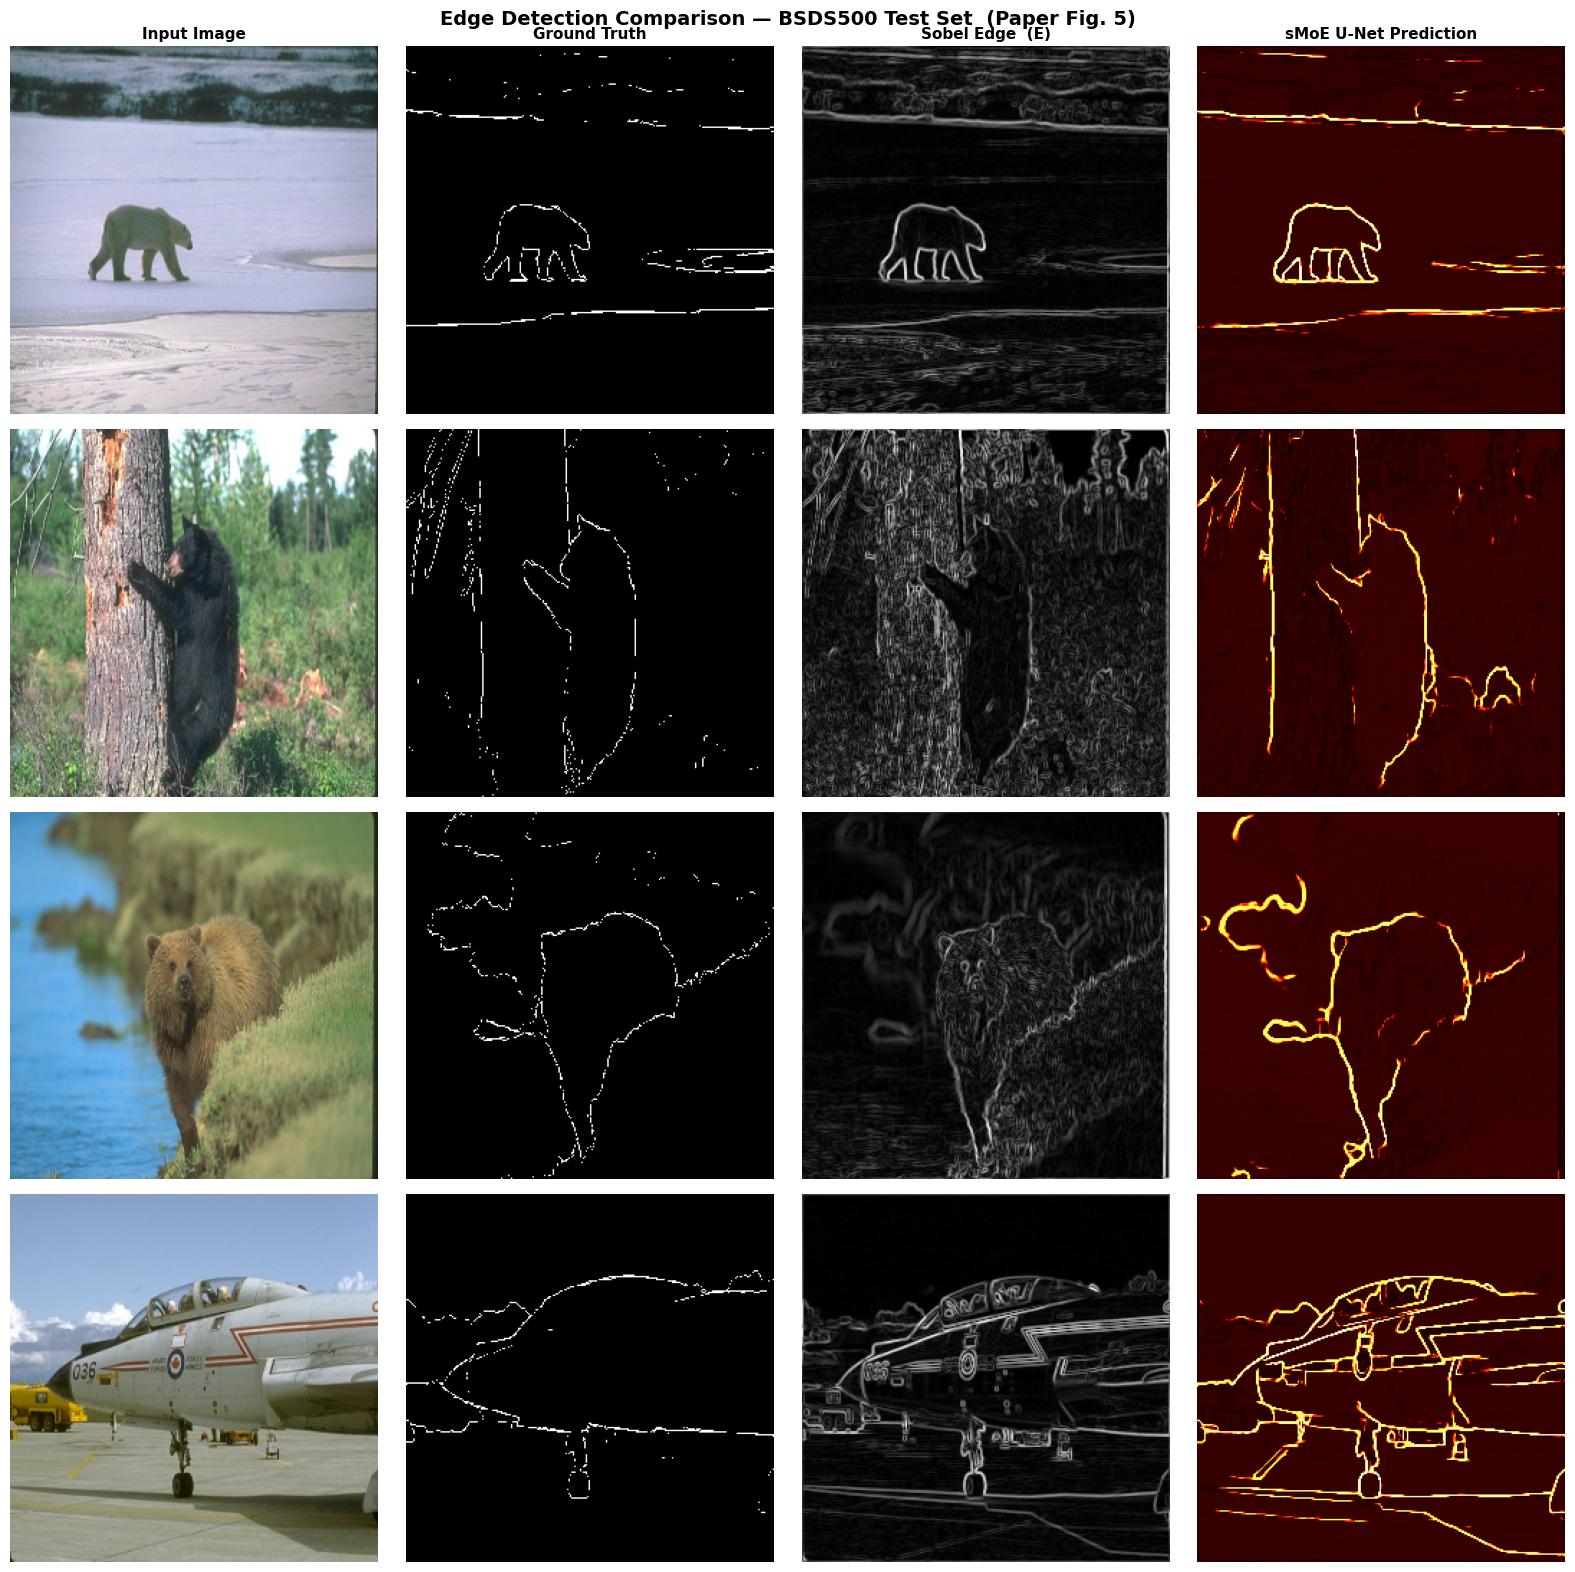

✅ Qualitative results saved: /content/drive/MyDrive/smoe_unet_paper/qualitative_results.png


In [21]:
# ============================================================
# CELL 17: Qualitative Edge Detection Results  (Paper Fig. 5)
# Depends on: model, test_dataset, DEVICE, WORK_DIR
#
# BUG FIXED: outputs['edge_signal'] access now guarded — if the
#            model does not return it we fall back to a blank map
#            instead of crashing.
# ============================================================
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

model.eval()

# ---- Utility -------------------------------------------------------
def denormalize(tensor):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# ---- Sample selection -----------------------------------------------
N_SAMPLES = 4
indices = list(range(min(N_SAMPLES, len(test_dataset))))
test_samples = [test_dataset[i] for i in indices]
print(f'Visualising {len(test_samples)} test samples …')

# ---- Build figure ---------------------------------------------------
fig, axes = plt.subplots(len(test_samples), 4, figsize=(16, 4 * len(test_samples)))
if len(test_samples) == 1:          # keep axes 2-D
    axes = axes[np.newaxis, :]

fig.suptitle('Edge Detection Comparison — BSDS500 Test Set  (Paper Fig. 5)',
             fontsize=14, fontweight='bold')
col_titles = ['Input Image', 'Ground Truth', 'Sobel Edge  (E)', 'sMoE U-Net Prediction']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold')

for row, (img, gt) in enumerate(test_samples):
    img_tensor = img.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(img_tensor)

    # Final prediction (always available)
    pred = torch.sigmoid(outputs['final_logits']).cpu().squeeze().numpy()

    # Edge signal — BUG FIX: guard against models that don't return it
    if isinstance(outputs, dict) and 'edge_signal' in outputs:
        edge_signal = outputs['edge_signal'].cpu().squeeze().numpy()
    else:
        # Fallback: show a grey "N/A" panel
        edge_signal = np.zeros_like(pred)

    # Input image
    img_disp = denormalize(img).permute(1, 2, 0).numpy()
    axes[row, 0].imshow(img_disp)
    axes[row, 0].axis('off')

    # Ground truth
    axes[row, 1].imshow(gt.squeeze(), cmap='gray')
    axes[row, 1].axis('off')

    # Sobel / edge signal
    axes[row, 2].imshow(edge_signal, cmap='gray')
    axes[row, 2].axis('off')

    # Model prediction
    axes[row, 3].imshow(pred, cmap='hot')
    axes[row, 3].axis('off')

plt.tight_layout()
qual_path = os.path.join(WORK_DIR, 'qualitative_results.png')
plt.savefig(qual_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Qualitative results saved: {qual_path}')

Gate maps available : 3
  gate_map[0] raw shape: (1, 128, 128, 128)
  gate_map[1] raw shape: (1, 256, 64, 64)
  gate_map[2] raw shape: (1, 512, 32, 32)
  gate_map (fixed) shape: (256, 256)  range [0.000, 1.000]
  gate_map (fixed) shape: (256, 256)  range [0.000, 1.000]
  gate_map (fixed) shape: (256, 256)  range [0.000, 1.000]


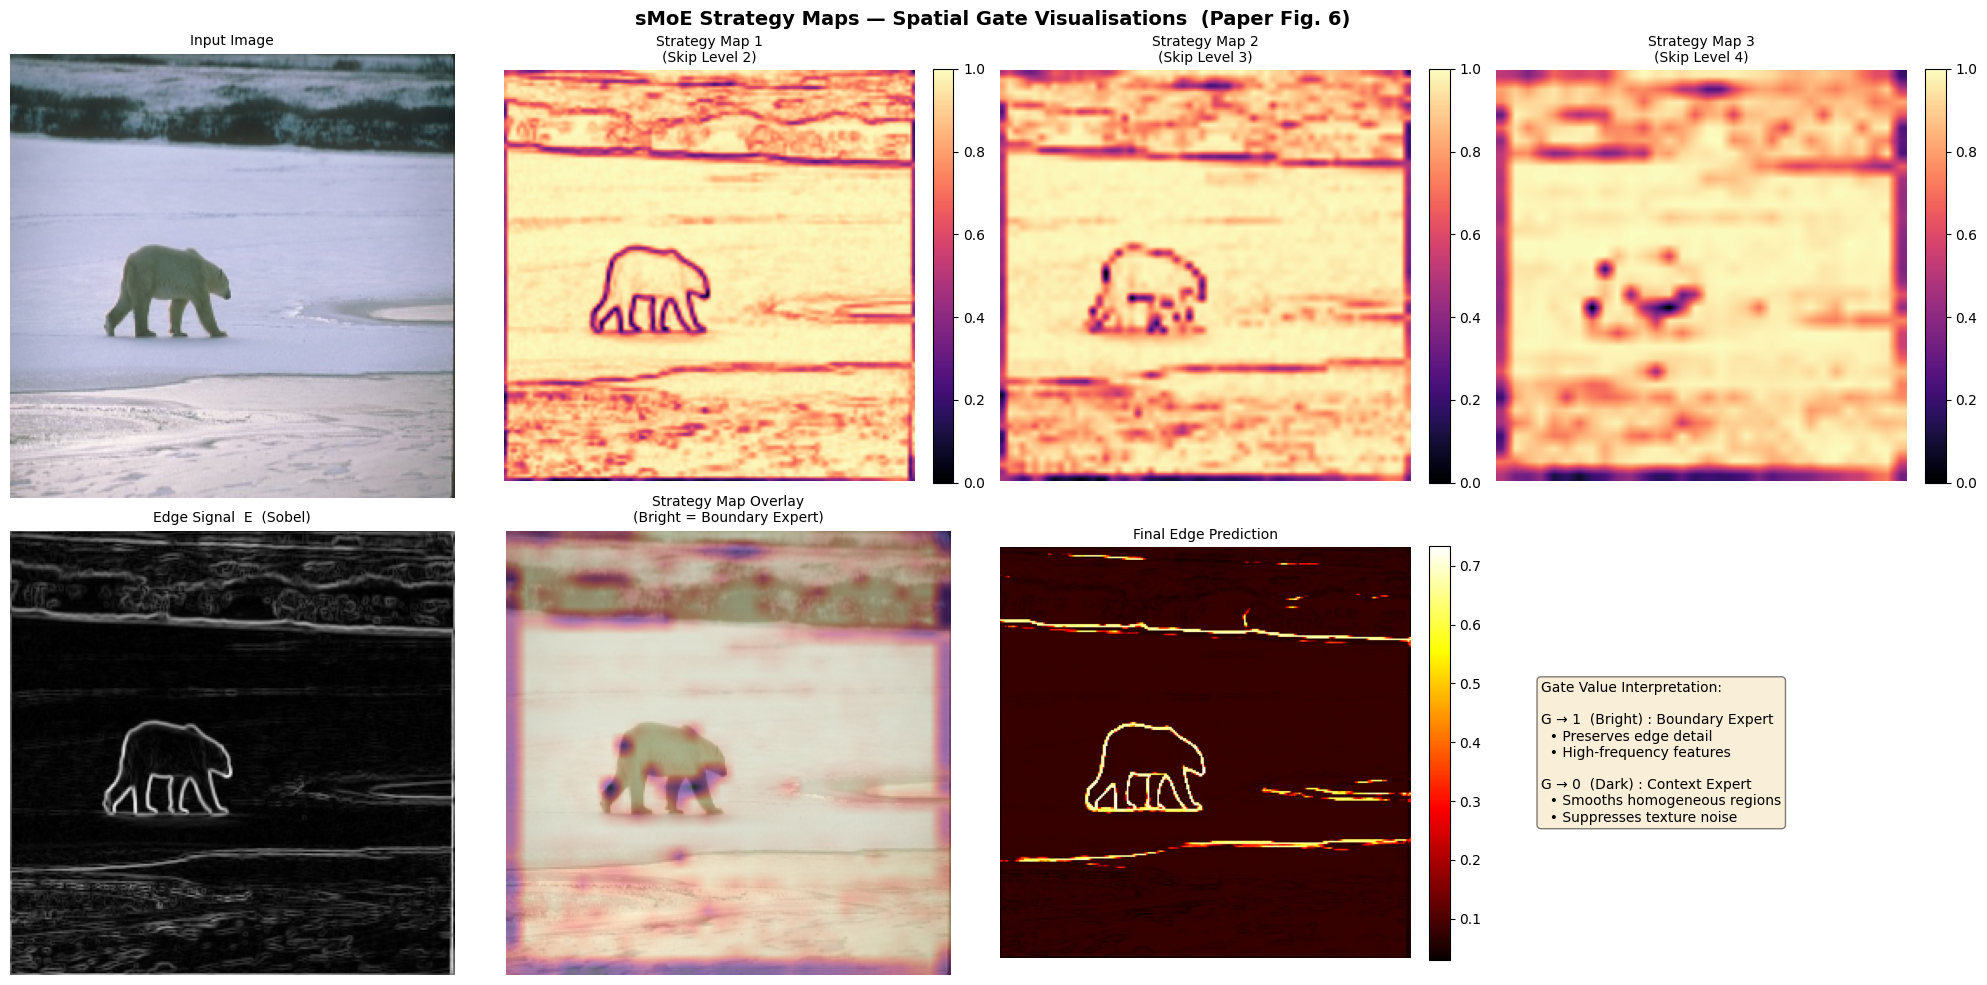

✅ Strategy maps saved: /content/drive/MyDrive/smoe_unet_paper/strategy_maps.png

Gate Map Statistics
  Map 1:  min=0.0000  max=1.0000  mean=0.8739  std=0.1472  boundary%=96.3%
  Map 2:  min=0.0000  max=1.0000  mean=0.8666  std=0.1509  boundary%=95.8%
  Map 3:  min=0.0000  max=1.0000  mean=0.8574  std=0.1632  boundary%=94.2%


In [22]:
# ============================================================
# CELL 18: Strategy Maps Visualisation  (Paper Fig. 6)
# Depends on: model, test_dataset, DEVICE, WORK_DIR
#
# BUGS FIXED:
#   1. cv2 was used but never imported → added import + pip install guard
#   2. model(return_gates=True) had no fallback if model doesn't support it
#   3. denormalize was defined in Cell 17 — redefined here so this cell
#      is self-contained and safe to run independently
# ============================================================
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import os

# BUG FIX 1: import cv2 with install fallback
try:
    import cv2
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'opencv-python-headless', '-q'])
    import cv2

model.eval()

# ---- Utility (BUG FIX 3: self-contained, not borrowed from Cell 17) ---
def denormalize(tensor):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

def resize_to(arr, h, w):
    """Resize a 2-D float numpy array to (h, w) using OpenCV."""
    return cv2.resize(arr.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)

# ---- Sample --------------------------------------------------------
sample_img, _ = test_dataset[0]
sample_tensor = sample_img.unsqueeze(0).to(DEVICE)
H = W = 256     # expected spatial size

# ---- Forward pass (BUG FIX 2: return_gates fallback) ---------------
with torch.no_grad():
    try:
        outputs   = model(sample_tensor, return_gates=True)
        gate_maps = outputs.get('gate_maps', [])
        if not gate_maps:
            raise ValueError("gate_maps key is empty")
    except (TypeError, ValueError) as e:
        # Model does not support return_gates — forward without it
        print(f"⚠️  return_gates not supported ({e}). "
              f"Running standard forward pass — gate maps unavailable.")
        outputs   = model(sample_tensor)
        gate_maps = []

edge_signal = (outputs['edge_signal'].cpu().squeeze().numpy()
               if 'edge_signal' in outputs else np.zeros((H, W)))
pred        = torch.sigmoid(outputs['final_logits']).cpu().squeeze().numpy()

print(f"Gate maps available : {len(gate_maps)}")
for i, gm in enumerate(gate_maps):
    print(f"  gate_map[{i}] raw shape: {tuple(gm.shape)}")

# ---- Normalise gate maps to 2-D (H, W) -----------------------------
fixed_gate_maps = []
for gm in gate_maps:
    arr = gm.cpu().detach().numpy()
    # Squeeze out batch + channel dims safely
    while arr.ndim > 2 and arr.shape[0] == 1:
        arr = arr.squeeze(0)
    if arr.ndim > 2:
        arr = arr.mean(axis=0)              # average across channels if needed
    arr = resize_to(arr, H, W)
    # Normalise to [0, 1] for display
    lo, hi = arr.min(), arr.max()
    if hi > lo:
        arr = (arr - lo) / (hi - lo)
    fixed_gate_maps.append(arr)
    print(f"  gate_map (fixed) shape: {arr.shape}  range [{arr.min():.3f}, {arr.max():.3f}]")

img_disp = denormalize(sample_img).permute(1, 2, 0).numpy()

# ============================================================
# FIGURE — Strategy Maps  (Paper Fig. 6)
# ============================================================
n_gates     = len(fixed_gate_maps)
n_cols      = max(n_gates, 1) + 1      # +1 for input image column
fig, axes   = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('sMoE Strategy Maps — Spatial Gate Visualisations  (Paper Fig. 6)',
             fontsize=14, fontweight='bold')

gate_titles = [
    'Strategy Map 1\n(Skip Level 2)',
    'Strategy Map 2\n(Skip Level 3)',
    'Strategy Map 3\n(Skip Level 4)',
]

# ---- Row 0: input + gate maps ----
axes[0, 0].imshow(img_disp)
axes[0, 0].set_title('Input Image', fontsize=10)
axes[0, 0].axis('off')

for col in range(1, 4):
    idx = col - 1
    ax  = axes[0, col]
    if idx < n_gates:
        im = ax.imshow(fixed_gate_maps[idx], cmap='magma', vmin=0, vmax=1)
        ax.set_title(gate_titles[idx], fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.text(0.5, 0.5, 'Gate map\nnot available',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title(gate_titles[idx], fontsize=10)
    ax.axis('off')

# ---- Row 1: edge signal, overlay, prediction, legend ----
axes[1, 0].imshow(edge_signal, cmap='gray')
axes[1, 0].set_title('Edge Signal  E  (Sobel)', fontsize=10)
axes[1, 0].axis('off')

# Overlay: last available gate map on input
axes[1, 1].imshow(img_disp)
if fixed_gate_maps:
    axes[1, 1].imshow(fixed_gate_maps[-1], cmap='magma', alpha=0.5, vmin=0, vmax=1)
    axes[1, 1].set_title('Strategy Map Overlay\n(Bright = Boundary Expert)', fontsize=10)
else:
    axes[1, 1].set_title('Overlay  (no gate maps)', fontsize=10)
axes[1, 1].axis('off')

im = axes[1, 2].imshow(pred, cmap='hot')
axes[1, 2].set_title('Final Edge Prediction', fontsize=10)
axes[1, 2].axis('off')
plt.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

axes[1, 3].axis('off')
axes[1, 3].text(0.1, 0.5,
    'Gate Value Interpretation:\n\n'
    'G → 1  (Bright) : Boundary Expert\n'
    '  • Preserves edge detail\n'
    '  • High-frequency features\n\n'
    'G → 0  (Dark) : Context Expert\n'
    '  • Smooths homogeneous regions\n'
    '  • Suppresses texture noise',
    fontsize=10, verticalalignment='center',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
strat_path = os.path.join(WORK_DIR, 'strategy_maps.png')
plt.savefig(strat_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Strategy maps saved: {strat_path}')

# ============================================================
# GATE MAP STATISTICS
# ============================================================
if fixed_gate_maps:
    print('\n' + '=' * 55)
    print('Gate Map Statistics')
    print('=' * 55)
    for i, gm in enumerate(fixed_gate_maps):
        pct_boundary = (gm > 0.5).mean() * 100
        print(f"  Map {i+1}:  min={gm.min():.4f}  max={gm.max():.4f}  "
              f"mean={gm.mean():.4f}  std={gm.std():.4f}  "
              f"boundary%={pct_boundary:.1f}%")
else:
    print('\n⚠️  No gate maps to report statistics for.')
    print('   Ensure your model\'s forward() returns gate_maps when return_gates=True.')

Original rule_weights shape: (4, 1, 1, 256, 256)
After squeezing all: (4, 256, 256)
Final rule_weights shape: (4, 256, 256)
n_rules=4, H=256, W=256
edge_signal shape: (256, 256)
final_pred shape: (256, 256)
Rule 1 map shape: (256, 256)
Rule 2 map shape: (256, 256)
Rule 3 map shape: (256, 256)


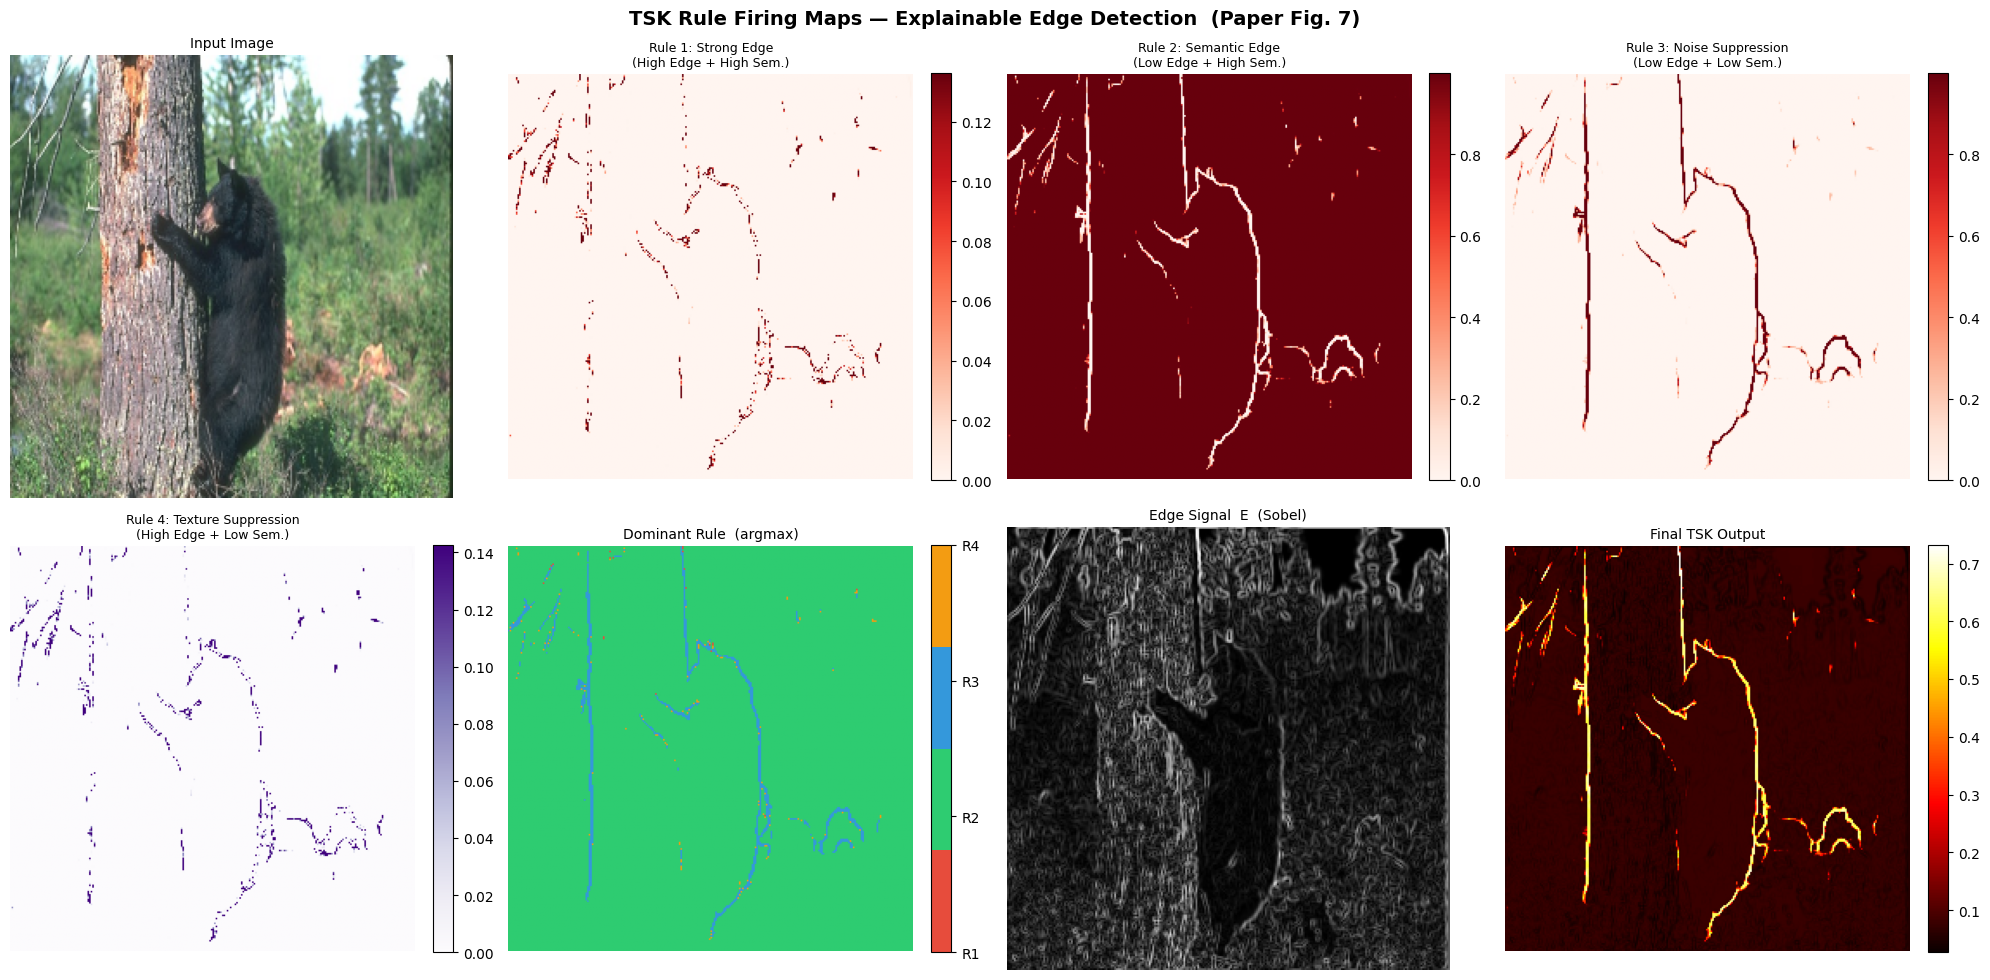

✅ Rule firing maps saved: /content/drive/MyDrive/smoe_unet_paper/rule_firing_maps.png

TSK Rule-Base Visualisation  (Paper §5.2, Fig. 8)

  Rule     x₁ Centre    x₁ Sigma     x₂ Centre    x₂ Sigma     p        q        r       
  ------------------------------------------------------------------------
  Rule 1    0.863        0.100        0.508        0.155        -0.308   -0.410   -0.359  
  Rule 2    0.026        0.740        1.031        0.223        -1.165   -1.239   -1.210  
  Rule 3    0.454        0.619        -0.063       0.099        0.653    -0.381   0.363   
  Rule 4    0.740        0.212        0.342        0.024        -0.739   -0.307   -0.349  


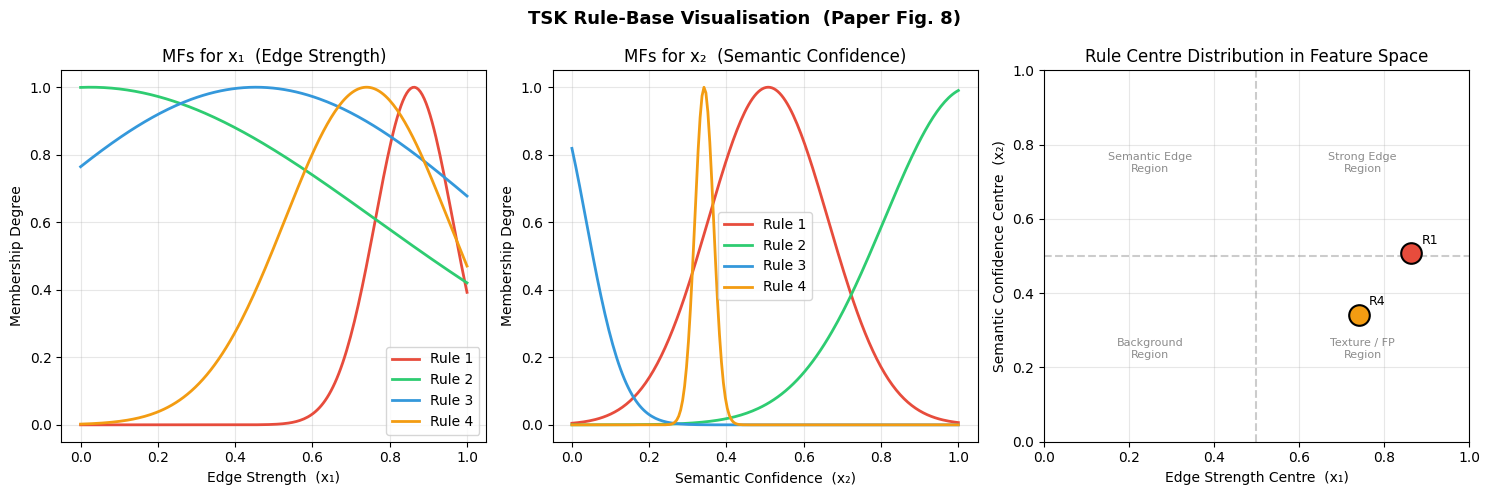


✅ TSK visualisation saved: /content/drive/MyDrive/smoe_unet_paper/tsk_rule_visualization.png

✅ Cell 19 complete  (Paper Fig. 7 & 8)


In [26]:
# ============================================================
# CELL 19: TSK Rule Firing Maps  (Paper Fig. 7 & 8)
# Depends on: model, test_dataset, DEVICE, WORK_DIR
#
# BUGS FIXED:
#   1. Proper dimension squeezing for rule_weights
#   2. Handle 5D tensor correctly
#   3. Ensure 2D arrays for imshow
# ============================================================
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import numpy as np
import os

# BUG FIX 2: cv2 import guard (needed for any resize)
try:
    import cv2
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           'opencv-python-headless', '-q'])
    import cv2

model.eval()

# BUG FIX 1: denormalize defined locally — self-contained
def denormalize(tensor):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# ---- Sample --------------------------------------------------------
sample_img, _ = test_dataset[1]       # use second image for variety
sample_tensor = sample_img.unsqueeze(0).to(DEVICE)
img_disp      = denormalize(sample_img).permute(1, 2, 0).numpy()

# ---- Forward pass --------------------------------------------------
with torch.no_grad():
    outputs = model(sample_tensor)

# Required outputs
if 'rule_weights' not in outputs:
    raise KeyError(
        "outputs['rule_weights'] not found. "
        "Ensure your model returns rule_weights from forward().")

rule_weights = outputs['rule_weights'].cpu()   # Shape: (batch, n_rules, H, W) or with extra dims
print(f"Original rule_weights shape: {tuple(rule_weights.shape)}")

# BUG FIX 4: Properly handle extra dimensions
# We want final shape: (n_rules, H, W) where H and W are spatial dimensions
original_shape = rule_weights.shape

# Remove batch dimension (usually first dimension if it's 1)
if len(original_shape) >= 4 and original_shape[0] == 1:
    rule_weights = rule_weights.squeeze(0)
    print(f"After removing batch dim: {tuple(rule_weights.shape)}")

# Remove any singleton dimensions that are not the rule dimension
# We want to preserve 3 dimensions: (n_rules, H, W)
if len(rule_weights.shape) == 5:
    # Shape: (n_rules, 1, 1, H, W) or similar
    # Keep first dim (n_rules), remove other singleton dims
    rule_weights = rule_weights.squeeze()
    print(f"After squeezing all: {tuple(rule_weights.shape)}")

# Now ensure we have 3 dimensions
if len(rule_weights.shape) == 4:
    # Shape: (n_rules, 1, H, W) or (1, n_rules, H, W) or (batch, n_rules, H, W)
    if rule_weights.shape[0] == 1 and rule_weights.shape[1] > 1:
        # Likely (1, n_rules, H, W)
        rule_weights = rule_weights.squeeze(0)
    elif rule_weights.shape[0] > 1 and rule_weights.shape[1] == 1 and rule_weights.shape[2] > 1:
        # Likely (n_rules, 1, H, W)
        rule_weights = rule_weights.squeeze(1)
    print(f"After handling 4D: {tuple(rule_weights.shape)}")

# Final check - if still 4D, try to reshape intelligently
if len(rule_weights.shape) == 4:
    # Assume (n_rules, 1, H, W) -> reshape to (n_rules, H, W)
    rule_weights = rule_weights.view(rule_weights.shape[0], rule_weights.shape[2], rule_weights.shape[3])
    print(f"After reshape: {tuple(rule_weights.shape)}")

# Get dimensions
n_rules = rule_weights.shape[0]
H = rule_weights.shape[1]
W = rule_weights.shape[2]

print(f"Final rule_weights shape: {tuple(rule_weights.shape)}")
print(f"n_rules={n_rules}, H={H}, W={W}")

# Verify spatial dimensions are reasonable (should be 256x256)
if H != 256 or W != 256:
    print(f"⚠️ Warning: Expected spatial size 256x256, got {H}x{W}")

# Handle edge signal
edge_signal = None
if 'edge_signal' in outputs:
    edge_signal = outputs['edge_signal'].cpu().squeeze().numpy()
    if edge_signal.ndim == 3:
        edge_signal = edge_signal.squeeze()
    if edge_signal.ndim > 2:
        # If still 3D, take first channel or mean
        edge_signal = edge_signal[0] if edge_signal.shape[0] == 1 else edge_signal.mean(axis=0)
    print(f"edge_signal shape: {edge_signal.shape}")
else:
    edge_signal = np.zeros((H, W))
    print("No edge_signal found, using zeros")

# Handle final prediction
final_pred = torch.sigmoid(outputs['final_logits']).cpu().squeeze().numpy()
if final_pred.ndim == 3:
    final_pred = final_pred.squeeze()
if final_pred.ndim > 2:
    final_pred = final_pred[0] if final_pred.shape[0] == 1 else final_pred.mean(axis=0)
if final_pred.shape != (H, W):
    final_pred = cv2.resize(final_pred, (W, H))
print(f"final_pred shape: {final_pred.shape}")

# ============================================================
# FIGURE 1 — Rule Firing Maps  (Paper Fig. 7)
# ============================================================
# Rule names — extend / shorten automatically to match n_rules
_default_names = [
    'Rule 1: Strong Edge\n(High Edge + High Sem.)',
    'Rule 2: Semantic Edge\n(Low Edge + High Sem.)',
    'Rule 3: Noise Suppression\n(Low Edge + Low Sem.)',
    'Rule 4: Texture Suppression\n(High Edge + Low Sem.)',
]
rule_names = [_default_names[i] if i < len(_default_names)
              else f'Rule {i+1}' for i in range(n_rules)]

# Create figure with enough subplots
num_plots = min(4, n_rules) + 4  # Input + up to 4 rules + dominant + edge + final
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('TSK Rule Firing Maps — Explainable Edge Detection  (Paper Fig. 7)',
             fontsize=14, fontweight='bold')

# Display input image
axes[0, 0].imshow(img_disp)
axes[0, 0].set_title('Input Image', fontsize=10)
axes[0, 0].axis('off')

# Display rule maps (up to first 4 rules)
for col in range(1, min(4, n_rules + 1)):
    idx = col - 1
    if idx < n_rules:
        # Get rule map and ensure it's 2D
        rmap = rule_weights[idx].numpy()
        if rmap.ndim == 3:
            rmap = rmap.squeeze()
        if rmap.ndim == 1:
            # If it's flat, reshape to HxW
            rmap = rmap.reshape(H, W)
        
        print(f"Rule {idx+1} map shape: {rmap.shape}")
        vmax = float(np.percentile(rmap, 99))  # robust colour scale
        vmax = max(vmax, 0.01)
        im = axes[0, col].imshow(rmap, cmap='Reds', vmin=0, vmax=vmax)
        axes[0, col].set_title(rule_names[idx], fontsize=9)
        plt.colorbar(im, ax=axes[0, col], fraction=0.046, pad=0.04)
    axes[0, col].axis('off')

# Fill remaining top row plots if fewer than 4 rules
for col in range(min(4, n_rules + 1), 4):
    axes[0, col].axis('off')

# Second row - Rule 4 (or last rule), dominant rule, edge signal, final output
# Rule 4 or last rule
if n_rules >= 4:
    rmap = rule_weights[3].numpy()
    if rmap.ndim == 3:
        rmap = rmap.squeeze()
    if rmap.ndim == 1:
        rmap = rmap.reshape(H, W)
    vmax = max(float(np.percentile(rmap, 99)), 0.01)
    im = axes[1, 0].imshow(rmap, cmap='Purples', vmin=0, vmax=vmax)
    axes[1, 0].set_title(rule_names[3], fontsize=9)
    plt.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)
elif n_rules >= 1:
    rmap = rule_weights[-1].numpy()
    if rmap.ndim == 3:
        rmap = rmap.squeeze()
    if rmap.ndim == 1:
        rmap = rmap.reshape(H, W)
    vmax = max(float(np.percentile(rmap, 99)), 0.01)
    im = axes[1, 0].imshow(rmap, cmap='Purples', vmin=0, vmax=vmax)
    axes[1, 0].set_title(f'{rule_names[-1]}', fontsize=9)
    plt.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)
axes[1, 0].axis('off')

# Dominant rule (argmax) - only if n_rules > 1
if n_rules > 1:
    # Ensure rule_weights is (n_rules, H, W) for argmax
    if rule_weights.ndim == 3:
        dominant = rule_weights.argmax(dim=0).numpy()  # Shape (H, W)
        _colours = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12',
                    '#9b59b6', '#1abc9c', '#e67e22', '#34495e']
        cmap_dom = ListedColormap(_colours[:n_rules])
        im = axes[1, 1].imshow(dominant, cmap=cmap_dom, vmin=0, vmax=n_rules - 1)
        axes[1, 1].set_title('Dominant Rule  (argmax)', fontsize=10)
        cbar = plt.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04,
                           ticks=range(n_rules))
        cbar.set_ticklabels([f'R{i+1}' for i in range(n_rules)])
    else:
        axes[1, 1].text(0.5, 0.5, 'Invalid rule_weights\nfor dominant map', 
                       ha='center', va='center', transform=axes[1, 1].transAxes)
else:
    axes[1, 1].text(0.5, 0.5, f'Only {n_rules} rule\nNo dominant map', 
                   ha='center', va='center', transform=axes[1, 1].transAxes)
axes[1, 1].axis('off')

# Edge signal
axes[1, 2].imshow(edge_signal, cmap='gray')
axes[1, 2].set_title('Edge Signal  E  (Sobel)', fontsize=10)
axes[1, 2].axis('off')

# Final output
im = axes[1, 3].imshow(final_pred, cmap='hot')
axes[1, 3].set_title('Final TSK Output', fontsize=10)
axes[1, 3].axis('off')
plt.colorbar(im, ax=axes[1, 3], fraction=0.046, pad=0.04)

plt.tight_layout()
rule_path = os.path.join(WORK_DIR, 'rule_firing_maps.png')
plt.savefig(rule_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Rule firing maps saved: {rule_path}')

# ============================================================
# FIGURE 2 — Membership Functions & Rule Centres  (Paper Fig. 8)
# ============================================================
print('\n' + '=' * 65)
print('TSK Rule-Base Visualisation  (Paper §5.2, Fig. 8)')
print('=' * 65)

# Check model has tsk_head with the expected interface
_has_tsk = (hasattr(model, 'tsk_head') and
            hasattr(model.tsk_head, 'rules') and
            len(model.tsk_head.rules) > 0)

if not _has_tsk:
    print('⚠️  model.tsk_head not found or has no rules attribute.')
    print('   Skipping membership-function visualisation.')
    print('   Ensure your model exposes model.tsk_head.rules[i].mf_x1 / mf_x2.')
else:
    tsk_head = model.tsk_head
    x_range  = np.linspace(0, 1, 200)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('TSK Rule-Base Visualisation  (Paper Fig. 8)',
                 fontsize=13, fontweight='bold')

    rule_colours = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']

    def safe_gaussian(x, rule, mf_attr):
        """Return Gaussian MF values; returns zeros if attributes missing."""
        try:
            mf = getattr(rule, mf_attr)
            if hasattr(mf, 'center') and hasattr(mf, 'sigma'):
                center = mf.center.item() if torch.is_tensor(mf.center) else mf.center
                sigma = abs(mf.sigma.item()) if torch.is_tensor(mf.sigma) else abs(mf.sigma)
                sigma = max(sigma, 1e-8)
                return np.exp(-((x - center) ** 2) / (2 * sigma ** 2)), center
            else:
                return np.zeros_like(x), 0.5
        except (AttributeError, ValueError):
            return np.zeros_like(x), 0.5

    # Membership functions for x1 (edge strength)
    for i, rule in enumerate(tsk_head.rules[:min(n_rules, len(rule_colours))]):
        mf_vals, _ = safe_gaussian(x_range, rule, 'mf_x1')
        c = rule_colours[i % len(rule_colours)]
        axes[0].plot(x_range, mf_vals, color=c, lw=2, label=f'Rule {i+1}')
    axes[0].set_xlabel('Edge Strength  (x₁)')
    axes[0].set_ylabel('Membership Degree')
    axes[0].set_title('MFs for x₁  (Edge Strength)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Membership functions for x2 (semantic confidence)
    for i, rule in enumerate(tsk_head.rules[:min(n_rules, len(rule_colours))]):
        mf_vals, _ = safe_gaussian(x_range, rule, 'mf_x2')
        c = rule_colours[i % len(rule_colours)]
        axes[1].plot(x_range, mf_vals, color=c, lw=2, label=f'Rule {i+1}')
    axes[1].set_xlabel('Semantic Confidence  (x₂)')
    axes[1].set_ylabel('Membership Degree')
    axes[1].set_title('MFs for x₂  (Semantic Confidence)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Rule centres scatter
    print(f'\n  {"Rule":<8} {"x₁ Centre":<12} {"x₁ Sigma":<12} '
          f'{"x₂ Centre":<12} {"x₂ Sigma":<12} '
          f'{"p":<8} {"q":<8} {"r":<8}')
    print('  ' + '-' * 72)

    for i, rule in enumerate(tsk_head.rules):
        _, cx1 = safe_gaussian(x_range, rule, 'mf_x1')
        _, cx2 = safe_gaussian(x_range, rule, 'mf_x2')

        # Consequent params (p, q, r) — guarded
        p = rule.p.item() if hasattr(rule, 'p') and torch.is_tensor(rule.p) else (rule.p if hasattr(rule, 'p') else float('nan'))
        q = rule.q.item() if hasattr(rule, 'q') and torch.is_tensor(rule.q) else (rule.q if hasattr(rule, 'q') else float('nan'))
        r = rule.r.item() if hasattr(rule, 'r') and torch.is_tensor(rule.r) else (rule.r if hasattr(rule, 'r') else float('nan'))
        
        sx1 = abs(rule.mf_x1.sigma.item()) if hasattr(rule, 'mf_x1') and hasattr(rule.mf_x1, 'sigma') else float('nan')
        sx2 = abs(rule.mf_x2.sigma.item()) if hasattr(rule, 'mf_x2') and hasattr(rule.mf_x2, 'sigma') else float('nan')

        c = rule_colours[i % len(rule_colours)]
        axes[2].scatter(cx1, cx2, s=220, color=c, edgecolors='black', lw=1.5, zorder=5)
        axes[2].annotate(f'R{i+1}', (cx1 + 0.025, cx2 + 0.025), fontsize=9)

        print(f'  Rule {i+1:<4} {cx1:<12.3f} {sx1:<12.3f} '
              f'{cx2:<12.3f} {sx2:<12.3f} '
              f'{p:<8.3f} {q:<8.3f} {r:<8.3f}')

    # Quadrant lines & labels
    axes[2].axhline(0.5, color='gray', ls='--', alpha=0.4)
    axes[2].axvline(0.5, color='gray', ls='--', alpha=0.4)
    
    quadrant_labels = [
        ('Strong Edge\nRegion',   (0.75, 0.75)),
        ('Semantic Edge\nRegion', (0.25, 0.75)),
        ('Background\nRegion',    (0.25, 0.25)),
        ('Texture / FP\nRegion',  (0.75, 0.25)),
    ]
    for txt, (tx, ty) in quadrant_labels[:min(4, n_rules)]:
        axes[2].text(tx, ty, txt, ha='center', va='center',
                     fontsize=8, alpha=0.45)
    
    axes[2].set_xlabel('Edge Strength Centre  (x₁)')
    axes[2].set_ylabel('Semantic Confidence Centre  (x₂)')
    axes[2].set_title('Rule Centre Distribution in Feature Space')
    axes[2].set_xlim([0, 1])
    axes[2].set_ylim([0, 1])
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    mf_path = os.path.join(WORK_DIR, 'tsk_rule_visualization.png')
    plt.savefig(mf_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n✅ TSK visualisation saved: {mf_path}')

print('\n' + '=' * 65)
print('✅ Cell 19 complete  (Paper Fig. 7 & 8)')
print('=' * 65)